#  MaisonDeLUX : Modèle Prédictif des Prix d'Appartements au Maroc

## 1. Contexte et Objectif du Projet
Ce projet s'inscrit dans le cadre de la plateforme **MaisonDeLUX**, visant à automatiser et fiabiliser l'estimation des prix immobiliers au Maroc. 
L'objectif principal est de développer un modèle de Machine Learning performant et robuste capable de prédire le prix de vente d'un appartement (`price_mad`) sur la base de caractéristiques intrinsèques et géographiques accessibles publiquement sur le site source.

**siteweb URL : maison-delux.com** 

## 2. Source des Données
* **Origine :** Annonces immobilières récupérées (*scraping*) de la plateforme  < https://www.mubawab.ma/ >.
* **Volume Global :** 13 537 annonces après réparation, réparties sur 10 régions et 30 villes ; les appartements sont majoritaires (11 918 lignes). Les quartiers nettoyés comportent des valeurs indisponibles.
* **Granularité :** Chaque ligne représente une annonce destinée à la vente ; les doublons possibles sont conservés et regroupés lors de la séparation Train/Test.

## 3. Dictionnaire des Données & Variables

Le jeu de données nettoyé contient les colonnes officielles suivantes :

### A. Variable Cible (Target)
* **`price_mad`** : Prix demandé de l'appartement en Dirhams marocains (MAD). C'est la valeur que le modèle doit prédire.

### B. Caractéristiques d'Entrée (Features Autorisées)
* **Géographie :** 
  * `region` : Région administrative de l'annonce.
  * `city` : Ville concernée (ex: Tanger, Casablanca, Rabat, etc.).
  * `neighborhood` : Quartier précis de l'bien.
* **Caractéristiques Physiques :** 
  * `surface_m2` : Surface habitable totale en mètres carrés ($m^2$).
  * `bedrooms` : Nombre de chambres.
  * `bathrooms` : Nombre de salles de bains.
* **Commodités & Équipements :** 
  * `furnished_status` : Statut d'ameublement (souvent renseigné comme `unknown` si non spécifié).
  * `parking` : Présence ou non d'un parking.
  * `balcony` : Présence ou non d'un balcon.
  * `sea_view` : Présence ou non d'une vue sur mer.

| Field Name | Data Type | Sample Values / Description |
| :--- | :--- | :--- |
| `listing_id` | String | Unique identifier for each listing (e.g., `mubawab.ma:native:7751448`) |
| `source` | String | Platform source of the listing (e.g., `mubawab.ma`) |
| `source_listing_id` | Float | Original source platform ID number |
| `city` | String | City where the property is located (e.g., `Rabat`, `Marrakech`) |
| `neighborhood` | String | Neighborhood or district name (e.g., `Agdal`, `Guéliz`) |
| `region` | String | Administrative region (e.g., `Rabat-Salé-Kenitra`, `Marrakech-Safi`) |
| `latitude` | Float | Geographical latitude coordinate (currently null in dataset) |
| `longitude` | Float | Geographical longitude coordinate (currently null in dataset) |
| `surface_m2` | Float | Total surface area of the property in square meters |
| `bedrooms` | Float | Number of bedrooms available in the property |
| `bathrooms` | Float | Number of bathrooms available in the property |
| `furnished_status` | String | Furnishing status of the property (e.g., `unknown`, `furnished`) |
| `parking` | String | Availability of parking (e.g., `unknown`, `yes`) |
| `balcony` | String | Availability of a balcony (e.g., `unknown`, `yes`) |
| `sea_view` | String | Presence of sea view (e.g., `unknown`, `yes`) |
| `price_mad` | Float | Total listing price in Moroccan Dirhams (MAD) |
| `price_per_m2` | Float | Price calculated per square meter in MAD |
| `property_type` | String | Type of real estate property (e.g., `appartement`) |
| `transaction_type` | String | Type of real estate transaction (e.g., `sale`) |
| `publication_date` | Float | Original publication date timestamp (null in dataset) |
| `publication_date_status` | String | Status indicator for publication date |
| `scraped_at` | String | Timestamp when the data record was scraped |
| `url` | String | Web URL link to the original listing |
| `validation_status` | String | Record validation status (e.g., `valid`) |
| `validation_reasons` | Float | Reasons for validation failure or flags |
| `deduplication_status` | String | Status indicating uniqueness (e.g., `unique`) |
| `duplicate_of` | Float | Reference ID if marked as a duplicate |
| `title_raw` | String | Raw text title extracted from the source page |
| `price_raw` | String | Raw price text string (e.g., `2912500.0 MAD`) |
| `location_raw` | String | Raw location text string from the source page |
| `details_raw` | String | Raw details text string from the source page |
| `source_record_path` | String | Internal pipeline file storage path |

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">1- Importation des bibliothèques</h2>
</div>

In [1]:
import pandas as pd     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor ,plot_tree
from statistics import linear_regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer

In [2]:
from pathlib import Path


# ============================================================
# 1. LOAD NEW TRAIN + REAL TEST
# ============================================================

TRAIN_FILENAME = "maisondelux_train_augmented_safe_v2(1).csv"
TEST_FILENAME = "maisondelux_test_real_holdout_v2.csv"

search_dirs = [
    Path.cwd(),
    Path.cwd() / "data" / "processed",
    Path.cwd().parent / "data" / "processed",
    Path.cwd().parent.parent / "data" / "processed",
    Path.cwd().parent.parent.parent / "data" / "processed",
]

def find_file(filename):
    for folder in search_dirs:
        path = folder / filename
        if path.exists():
            return path

    raise FileNotFoundError(
        f"{filename} introuvable depuis {Path.cwd()}"
    )


train_path = find_file(TRAIN_FILENAME)
test_path = find_file(TEST_FILENAME)

train_raw = pd.read_csv(train_path, low_memory=False)
test_raw = pd.read_csv(test_path, low_memory=False)

print("Train original :", train_raw.shape)
print("Test réel      :", test_raw.shape)


# ============================================================
# 2. REMOVE DUPLICATE GROUPS SHARED WITH FINAL TEST
# ============================================================

train_groups = set(
    train_raw["duplicate_group_id"]
    .dropna()
    .astype(str)
)

test_groups = set(
    test_raw["duplicate_group_id"]
    .dropna()
    .astype(str)
)

overlap_groups = train_groups.intersection(test_groups)

print("Duplicate groups Train/Test :", len(overlap_groups))

train_safe_raw = train_raw[
    ~train_raw["duplicate_group_id"]
    .astype("string")
    .isin(overlap_groups)
].copy()


# ============================================================
# 3. CREATE REAL TRAIN + FULL AUGMENTED TRAIN
# ============================================================

# REAL uniquement → CV / tuning / sélection du modèle
train_real_raw = train_safe_raw[
    train_safe_raw["batch_id"] != "augmentation_v2"
].copy()

# REAL + AUGMENTATION → entraînement final
train_full_raw = train_safe_raw.copy()


print("\nAprès sécurité anti-leakage")
print("REAL train pour CV :", train_real_raw.shape)
print("FULL train final   :", train_full_raw.shape)
print("REAL test final    :", test_raw.shape)


# ============================================================
# 4. OLD NOTEBOOK COMPATIBILITY
# ============================================================

# Toute l'EDA du notebook va travailler uniquement
# sur les vraies données du TRAIN.
df = train_real_raw.copy()

# utilisé plus loin dans ton notebook
file_path = train_path

Train original : (21658, 57)
Test réel      : (2708, 57)
Duplicate groups Train/Test : 553

Après sécurité anti-leakage
REAL train pour CV : (10158, 57)
FULL train final   : (20987, 57)
REAL test final    : (2708, 57)


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">2- Compréhension des Données</h2>
</div>

In [3]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head(10)

Nombre de lignes : 10158
Nombre de colonnes : 57


,listing_id,source,source_listing_id,city,neighborhood,region,latitude,longitude,surface_m2,bedrooms,...,duplicate_group_id,duplicate_match_level,duplicate_keep,price_per_m2_original,price_per_m2_recomputed,numeric_consistency_status,outlier_decision,outlier_reasons,repair_exclusion_reason,is_model_ready
0,mubawab.ma:content:f789e69f0f252aa6f2c1b5cb,mubawab.ma,NaN,Marrakech,Route de Fez,Marrakech-Safi,NaN,NaN,55.0,1.0,...,NaN,NaN,True,12054.55,12054.55,consistent,not_flagged,NaN,NaN,True
1,mubawab.ma:content:762f8599e64f92fa8012ccaa,mubawab.ma,NaN,Casablanca,Les Hôpitaux,Casablanca-Settat,NaN,NaN,129.0,4.0,...,NaN,NaN,True,11627.91,11627.91,consistent,not_flagged,NaN,NaN,True
3,mubawab.ma:content:3cbd741c9c7b8c1d8de47946,mubawab.ma,NaN,Témara,Maghreb Arabi,Rabat-Salé-Kénitra,NaN,NaN,120.0,2.0,...,NaN,NaN,True,11500.00,11500.00,consistent,not_flagged,NaN,NaN,True
4,mubawab.ma:content:55b06dbf73a7f7897383833e,mubawab.ma,NaN,Casablanca,Val Fleury,Casablanca-Settat,NaN,NaN,79.0,2.0,...,NaN,NaN,True,17088.61,17088.61,consistent,not_flagged,NaN,NaN,True
5,mubawab.ma:native:8386906,mubawab.ma,8386906.0,Casablanca,Triangle d'Or,Casablanca-Settat,NaN,NaN,207.0,3.0,...,NaN,NaN,True,25120.77,25120.77,consistent,not_flagged,NaN,NaN,True
7,mubawab.ma:content:d6edb54c5c00e0f5bcb4ea57,mubawab.ma,NaN,Tanger,Castilla,Tanger-Tétouan-Al Hoceïma,NaN,NaN,91.0,2.0,...,NaN,NaN,True,10000.00,10000.00,consistent,not_flagged,NaN,NaN,True
8,mubawab.ma:content:8c56d624ec98046693a8679a,mubawab.ma,NaN,Fès,Route se Sefrou,Fès-Meknès,NaN,NaN,93.0,2.0,...,NaN,NaN,True,4838.71,4838.71,consistent,not_flagged,NaN,NaN,True
9,mubawab.ma:content:ae2b5eb8d82884fe8349b545,mubawab.ma,NaN,Agadir,Hay Mohammadi,Souss-Massa,NaN,NaN,70.0,2.0,...,NaN,NaN,True,10000.00,10000.00,consistent,not_flagged,NaN,NaN,True
10,mubawab.ma:content:bebab7e163b0658f55a3110c,mubawab.ma,NaN,Marrakech,Guéliz,Marrakech-Safi,NaN,NaN,91.0,2.0,...,NaN,NaN,True,18571.43,18571.43,consistent,not_flagged,NaN,NaN,True
11,mubawab.ma:content:76ddf973137fbdd9980405c1,mubawab.ma,NaN,Casablanca,Palmier,Casablanca-Settat,NaN,NaN,207.0,3.0,...,NaN,NaN,True,16666.67,16666.67,consistent,not_flagged,NaN,NaN,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10158 entries, 0 to 10828
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   listing_id                      10158 non-null  object 
 1   source                          10158 non-null  object 
 2   source_listing_id               2181 non-null   float64
 3   city                            10158 non-null  object 
 4   neighborhood                    10158 non-null  object 
 5   region                          10158 non-null  object 
 6   latitude                        0 non-null      float64
 7   longitude                       0 non-null      float64
 8   surface_m2                      10158 non-null  float64
 9   bedrooms                        10099 non-null  float64
 10  bathrooms                       10026 non-null  float64
 11  furnished_status                10158 non-null  object 
 12  parking                         10158

In [5]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

01. listing_id
02. source
03. source_listing_id
04. city
05. neighborhood
06. region
07. latitude
08. longitude
09. surface_m2
10. bedrooms
11. bathrooms
12. furnished_status
13. parking
14. balcony
15. sea_view
16. price_mad
17. price_per_m2
18. property_type
19. transaction_type
20. publication_date
21. publication_date_status
22. scraped_at
23. url
24. validation_status
25. validation_reasons
26. deduplication_status
27. duplicate_of
28. title_raw
29. price_raw
30. location_raw
31. details_raw
32. source_record_path
33. property_type_original
34. property_type_repaired
35. property_type_repair_evidence
36. neighborhood_original
37. neighborhood_clean
38. neighborhood_validation_status
39. neighborhood_rejection_reason
40. region_original
41. region_repair_status
42. bedrooms_original
43. bathrooms_original
44. batch_id
45. canonical_url_repaired
46. batch_anomaly_status
47. duplicate_status_repaired
48. duplicate_group_id
49. duplicate_match_level
50. duplicate_keep
51. price_per_m2

In [6]:
numeric_cols = df.select_dtypes(include="number").columns

print("Variables numériques :", len(numeric_cols))

df[numeric_cols].describe().T

Variables numériques : 16


,count,mean,std,min,25%,50%,75%,max
source_listing_id,2181.0,8.291250e+06,1.423459e+05,6766087.0,8261457.00,8331792.000,8380600.00,8408312.00
latitude,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surface_m2,10158.0,1.191001e+02,7.018057e+01,14.0,78.00,104.000,140.00,1750.00
bedrooms,10099.0,2.471235e+00,8.244862e-01,1.0,2.00,2.000,3.00,20.00
bathrooms,10026.0,1.856573e+00,8.154219e-01,1.0,1.00,2.000,2.00,15.00
price_mad,10158.0,1.915803e+06,1.663503e+06,60000.0,980000.00,1500000.000,2300000.00,34000000.00
price_per_m2,10158.0,1.605164e+04,9.788277e+03,1000.0,10307.69,14412.445,19402.99,149038.46
publication_date,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
validation_reasons,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

categorical_summary = pd.DataFrame({
    "dtype": df[categorical_cols].dtypes,
    "non_null": df[categorical_cols].notna().sum(),
    "missing": df[categorical_cols].isna().sum(),
    "unique": df[categorical_cols].nunique(dropna=True)
})

categorical_summary

,dtype,non_null,missing,unique
listing_id,object,10158,0,10158
source,object,10158,0,1
city,object,10158,0,30
neighborhood,object,10158,0,761
region,object,10158,0,10
furnished_status,object,10158,0,3
parking,object,10158,0,2
balcony,object,10158,0,2
sea_view,object,10158,0,2
property_type,object,10158,0,1


In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing = missing[
    missing["missing_count"] > 0
].sort_values("missing_percent", ascending=False)

missing

,missing_count,missing_percent
repair_exclusion_reason,10158,100.00
latitude,10158,100.00
longitude,10158,100.00
publication_date,10158,100.00
validation_reasons,10158,100.00
duplicate_of,10158,100.00
outlier_reasons,9940,97.85
neighborhood_rejection_reason,9740,95.89
duplicate_match_level,8045,79.20
duplicate_group_id,8045,79.20


In [9]:
unique_values = pd.DataFrame({
    "unique_values": df.nunique(dropna=True)
}).sort_values("unique_values")

unique_values

,unique_values
duplicate_of,0
publication_date,0
latitude,0
longitude,0
repair_exclusion_reason,0
validation_reasons,0
numeric_consistency_status,1
publication_date_status,1
duplicate_keep,1
validation_status,1


In [10]:
print("Doublons exacts :", df.duplicated().sum())

if "listing_id" in df.columns:
    print(
        "listing_id dupliqués :",
        df["listing_id"].duplicated().sum()
    )

if "duplicate_status_repaired" in df.columns:
    print("\nStatut des doublons :")
    print(df["duplicate_status_repaired"].value_counts(dropna=False))

Doublons exacts : 0
listing_id dupliqués : 0

Statut des doublons :
duplicate_status_repaired
unique                8065
possible_duplicate    2093
Name: count, dtype: int64


In [11]:
important_cols = [
    "source",
    "region",
    "city",
    "property_type_repaired",
    "transaction_type",
    "furnished_status",
    "parking",
    "balcony",
    "sea_view",
]

for col in important_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))


--- source ---
source
mubawab.ma    10158
Name: count, dtype: int64

--- region ---
region
Casablanca-Settat            5401
Marrakech-Safi               1955
Tanger-Tétouan-Al Hoceïma    1106
Rabat-Salé-Kénitra            806
Fès-Meknès                    429
Souss-Massa                   361
L'Oriental                     67
Béni Mellal-Khénifra           30
Laâyoune-Sakia El Hamra         2
Drâa-Tafilalet                  1
Name: count, dtype: int64

--- city ---
city
Casablanca     4914
Marrakech      1891
Tanger          969
Agadir          357
Rabat           307
Fès             240
Meknès          188
Mohammedia      185
Kénitra         183
Salé            159
Témara          154
El Jadida       141
Tétouan         112
Bouskoura        73
Oujda            62
Berrechid        61
Essaouira        50
Larache          23
Béni Mellal      16
Settat           14
Khouribga        14
Safi             14
Bouznika         13
Nador             5
Tiznit            4
Khémisset         3
Laâ

In [12]:
key_numeric_cols = [
    "price_mad",
    "surface_m2",
    "bedrooms",
    "bathrooms",
    "price_per_m2"
]

existing_cols = [
    col for col in key_numeric_cols
    if col in df.columns
]

df[existing_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price_mad,10158.0,1.915803e+06,1.663503e+06,60000.0,980000.00,1500000.000,2300000.00,34000000.00
surface_m2,10158.0,1.191001e+02,7.018057e+01,14.0,78.00,104.000,140.00,1750.00
bedrooms,10099.0,2.471235e+00,8.244862e-01,1.0,2.00,2.000,3.00,20.00
bathrooms,10026.0,1.856573e+00,8.154219e-01,1.0,1.00,2.000,2.00,15.00
price_per_m2,10158.0,1.605164e+04,9.788277e+03,1000.0,10307.69,14412.445,19402.99,149038.46


### Conclusion de la compréhension des données

Le jeu de données final contient **13 537 observations et 57 variables**.

L'analyse initiale montre que les données ont déjà bénéficié d'un important travail de réparation : aucun doublon exact ni identifiant `listing_id` dupliqué n'est présent, et plusieurs variables corrigées telles que `property_type_repaired` et `neighborhood_clean` sont désormais disponibles.

Certaines limites restent toutefois présentes :

- plusieurs colonnes sont entièrement vides, notamment `latitude`, `longitude` et `publication_date` ;
- `source_listing_id` et `url` présentent un taux élevé de valeurs manquantes ;
- `bedrooms`, `bathrooms` et `neighborhood_clean` contiennent encore quelques valeurs manquantes ;
- 3 455 observations sont signalées comme doublons possibles, sans preuve suffisante pour les supprimer ;
- la représentation géographique est déséquilibrée entre les villes ;
- certaines valeurs extrêmes sont encore présentes dans le prix, la surface et le prix au m².

La prochaine étape consiste donc à réaliser un **nettoyage final ciblé**, sans supprimer agressivement les observations, afin de préparer les données à l'analyse exploratoire.

Les variables réparées (`property_type_repaired`, `neighborhood_clean`) seront privilégiées par rapport aux versions originales. La variable `price_per_m2` sera utilisée uniquement pour l'analyse exploratoire et non comme variable prédictive du prix afin d'éviter toute fuite de données.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">3- data cleaning</h2>
</div>

In [13]:
# Working copy for cleaning
df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaning copy shape:", df_clean.shape)

Original shape: (10158, 57)
Cleaning copy shape: (10158, 57)


In [14]:
empty_cols = [
    "latitude",
    "longitude",
    "publication_date",
    "validation_reasons",
    "duplicate_of",
    "repair_exclusion_reason"
]

df_clean = df_clean.drop(columns=empty_cols)

print("Shape après suppression :", df_clean.shape)

Shape après suppression : (10158, 51)


In [15]:
df_clean["property_type"] = df_clean["property_type_repaired"]
df_clean["neighborhood"] = df_clean["neighborhood_clean"]

print(df_clean["property_type"].value_counts(dropna=False))
print("\nNeighborhood missing :", df_clean["neighborhood"].isna().sum())

property_type
appartement    8916
unknown         953
studio          160
duplex           78
immeuble         28
villa             9
riad              7
maison            5
bureau            1
magasin           1
Name: count, dtype: int64

Neighborhood missing : 418


In [16]:
categorical_to_clean = [
    "city",
    "region",
    "neighborhood",
    "property_type",
    "furnished_status",
    "parking",
    "balcony",
    "sea_view"
]

for col in categorical_to_clean:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
    )

In [17]:
missing_by_type = (
    df_clean.groupby("property_type")
    .agg(
        count=("listing_id", "size"),
        missing_bedrooms=("bedrooms", lambda x: x.isna().sum()),
        missing_bathrooms=("bathrooms", lambda x: x.isna().sum()),
        missing_neighborhood=("neighborhood", lambda x: x.isna().sum())
    )
)

missing_by_type

,count,missing_bedrooms,missing_bathrooms,missing_neighborhood
property_type,,,,
appartement,8916,55,117,340
bureau,1,1,0,0
duplex,78,0,0,12
immeuble,28,0,1,0
magasin,1,1,0,0
maison,5,0,0,0
riad,7,0,0,1
studio,160,0,0,12
unknown,953,2,14,51


In [18]:
print("Prix invalides :", (df_clean["price_mad"] <= 0).sum())
print("Surfaces invalides :", (df_clean["surface_m2"] <= 0).sum())
print("Transactions non-sale :", (df_clean["transaction_type"] != "sale").sum())
print("Non model-ready :", (~df_clean["is_model_ready"]).sum())
print("Listing IDs dupliqués :", df_clean["listing_id"].duplicated().sum())

Prix invalides : 0
Surfaces invalides : 0
Transactions non-sale : 0
Non model-ready : 0
Listing IDs dupliqués : 0


In [19]:
df_clean["duplicate_status_repaired"].value_counts()

duplicate_status_repaired
unique                8065
possible_duplicate    2093
Name: count, dtype: int64

In [20]:
df_clean["outlier_decision"].value_counts(dropna=False)

outlier_decision
not_flagged      9940
uncertain         187
valid_extreme      31
Name: count, dtype: int64

In [21]:
df_clean.loc[
    df_clean["outlier_decision"].isin(["uncertain", "valid_extreme"]),
    [
        "city",
        "property_type",
        "surface_m2",
        "bedrooms",
        "bathrooms",
        "price_mad",
        "price_per_m2",
        "outlier_decision",
        "outlier_reasons"
    ]
].head(20)

,city,property_type,surface_m2,bedrooms,bathrooms,price_mad,price_per_m2,outlier_decision,outlier_reasons
19,Casablanca,immeuble,1288.0,20.0,10.0,17500000.0,13586.96,valid_extreme,surface_extreme|price_above_p99|bedrooms_above...
146,Casablanca,studio,42.0,1.0,1.0,4840000.0,115238.10,uncertain,price_per_m2_above_reference_p99
191,Casablanca,appartement,559.0,4.0,3.0,6950000.0,12432.92,uncertain,surface_extreme
248,El Jadida,unknown,256.0,6.0,2.0,11800000.0,46093.75,uncertain,price_above_p99|price_per_m2_above_reference_p99
283,Bouskoura,appartement,784.0,3.0,2.0,5200000.0,6632.65,uncertain,surface_extreme
451,Casablanca,appartement,65.0,5.0,3.0,3000000.0,46153.85,uncertain,price_per_m2_above_reference_p99
515,Marrakech,appartement,68.0,1.0,1.0,4920000.0,72352.94,uncertain,price_per_m2_above_reference_p99
543,Marrakech,appartement,56.0,3.0,NaN,4100000.0,73214.29,uncertain,price_per_m2_above_reference_p99
556,Tanger,appartement,124.0,3.0,2.0,6510000.0,52500.00,uncertain,price_per_m2_above_reference_p99
633,Casablanca,appartement,236.0,6.0,9.0,2900000.0,12288.14,uncertain,bathrooms_above_8


In [22]:
eda_cols = [
    "listing_id",
    "source",
    "region",
    "city",
    "neighborhood",
    "property_type",
    "surface_m2",
    "bedrooms",
    "bathrooms",
    "furnished_status",
    "parking",
    "balcony",
    "sea_view",
    "price_mad",
    "price_per_m2",
    "transaction_type",

    # Useful for auditing during EDA
    "batch_id",
    "duplicate_status_repaired",
    "duplicate_group_id",
    "outlier_decision",
    "outlier_reasons",
    "title_raw"
]

df_eda = df_clean[eda_cols].copy()

print("Dataset EDA :", df_eda.shape)
df_eda.head()

Dataset EDA : (10158, 22)


,listing_id,source,region,city,neighborhood,property_type,surface_m2,bedrooms,bathrooms,furnished_status,...,sea_view,price_mad,price_per_m2,transaction_type,batch_id,duplicate_status_repaired,duplicate_group_id,outlier_decision,outlier_reasons,title_raw
0,mubawab.ma:content:f789e69f0f252aa6f2c1b5cb,mubawab.ma,Marrakech-Safi,Marrakech,Route de Fez,unknown,55.0,1.0,1.0,unknown,...,unknown,663000.0,12054.55,sale,git_head_complete,unique,NaN,not_flagged,NaN,Residence prestige roof top
1,mubawab.ma:content:762f8599e64f92fa8012ccaa,mubawab.ma,Casablanca-Settat,Casablanca,Les Hôpitaux,appartement,129.0,4.0,2.0,unknown,...,unknown,1500000.0,11627.91,sale,git_head_complete,unique,NaN,not_flagged,NaN,"Appartement à Vendre de 129.0 m² à Casablanca,..."
3,mubawab.ma:content:3cbd741c9c7b8c1d8de47946,mubawab.ma,Rabat-Salé-Kénitra,Témara,Maghreb Arabi,appartement,120.0,2.0,2.0,unknown,...,unknown,1380000.0,11500.00,sale,git_head_complete,unique,NaN,not_flagged,NaN,"Appartement à vendre 120 m², 2 chambres Maghre..."
4,mubawab.ma:content:55b06dbf73a7f7897383833e,mubawab.ma,Casablanca-Settat,Casablanca,Val Fleury,unknown,79.0,2.0,2.0,unknown,...,unknown,1350000.0,17088.61,sale,git_head_complete,unique,NaN,not_flagged,NaN,Idéal investissement locatif
5,mubawab.ma:native:8386906,mubawab.ma,Casablanca-Settat,Casablanca,Triangle d'Or,appartement,207.0,3.0,3.0,unknown,...,unknown,5200000.0,25120.77,sale,recovery_misplaced_notebook,unique,NaN,not_flagged,NaN,NaN


### Conclusion du nettoyage

Le nettoyage final conserve **13 537 observations** exploitables.

Les colonnes entièrement vides ont été supprimées, et les variables corrigées `property_type_repaired` et `neighborhood_clean` ont été retenues.

Aucun prix, surface ou identifiant invalide n’a été détecté. Les valeurs manquantes restantes concernent surtout `neighborhood`, `bedrooms` et `bathrooms`.

Les doublons possibles et les valeurs extrêmes incertaines sont conservés pour être étudiés durant l’EDA, sans suppression automatique.

Le dataset `df_eda` est maintenant prêt pour l’analyse exploratoire.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">4- Analyse Exploratoire des Données</h2>
</div>

L'objectif de cette analyse exploratoire est de comprendre le comportement du marché immobilier représenté dans les données avant toute modélisation.

L'analyse cherchera notamment à comprendre la distribution des prix, l'effet de la surface et des caractéristiques du bien, les différences géographiques, le rôle des équipements, les catégories rares, les doublons possibles, les effets de lot de collecte et les observations extrêmes.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eda = df_eda.copy()

print("Dimensions du dataset EDA :", eda.shape)

Dimensions du dataset EDA : (10158, 22)


### 4.1 Analyse de la variable cible : `price_mad`

Cette première analyse vise à comprendre la distribution des prix, son asymétrie, l'influence éventuelle de valeurs très élevées et l'intérêt potentiel d'une transformation logarithmique.

In [24]:
price_stats = eda["price_mad"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)
price_stats

count    1.015800e+04
mean     1.915803e+06
std      1.663503e+06
min      6.000000e+04
1%       3.000000e+05
5%       4.600000e+05
10%      6.000000e+05
25%      9.800000e+05
50%      1.500000e+06
75%      2.300000e+06
90%      3.554400e+06
95%      4.500000e+06
99%      8.172000e+06
99.5%    1.060720e+07
max      3.400000e+07
Name: price_mad, dtype: float64

In [25]:
print("Moyenne :", round(eda["price_mad"].mean(), 2))
print("Médiane :", round(eda["price_mad"].median(), 2))
print("Écart-type :", round(eda["price_mad"].std(), 2))
print("Asymétrie (skewness) :", round(eda["price_mad"].skew(), 3))

Moyenne : 1915802.68
Médiane : 1500000.0
Écart-type : 1663503.33
Asymétrie (skewness) : 4.651


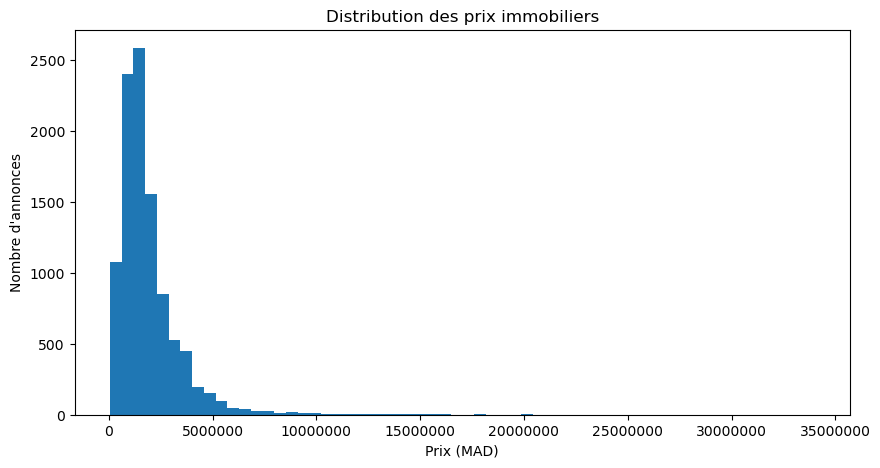

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(eda["price_mad"].dropna(), bins=60)
plt.title("Distribution des prix immobiliers")
plt.xlabel("Prix (MAD)")
plt.ylabel("Nombre d'annonces")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

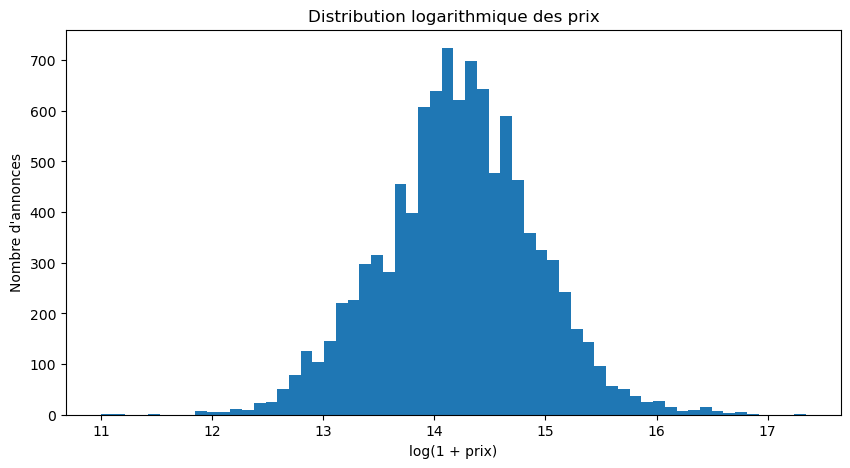

In [27]:
eda["log_price"] = np.log1p(eda["price_mad"])

plt.figure(figsize=(10, 5))
plt.hist(eda["log_price"].dropna(), bins=60)
plt.title("Distribution logarithmique des prix")
plt.xlabel("log(1 + prix)")
plt.ylabel("Nombre d'annonces")
plt.show()

In [28]:
quantiles_price = eda["price_mad"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
)
quantiles_price

0.500     1500000.0
0.750     2300000.0
0.900     3554400.0
0.950     4500000.0
0.990     8172000.0
0.995    10607200.0
1.000    34000000.0
Name: price_mad, dtype: float64

In [29]:
rounding_check = pd.Series({
    "multiple_10k": (eda["price_mad"] % 10_000 == 0).mean() * 100,
    "multiple_50k": (eda["price_mad"] % 50_000 == 0).mean() * 100,
    "multiple_100k": (eda["price_mad"] % 100_000 == 0).mean() * 100,
    "multiple_500k": (eda["price_mad"] % 500_000 == 0).mean() * 100,
}).round(2)

rounding_check.to_frame("pourcentage")

,pourcentage
multiple_10k,88.40
multiple_50k,63.34
multiple_100k,42.64
multiple_500k,10.76


#### Conclusion — Analyse de la variable cible

L'analyse de `price_mad` met en évidence une **forte asymétrie positive** de la distribution des prix.

Le prix médian est de **1 500 000 MAD**, tandis que le prix moyen atteint environ **1 916 804 MAD**. Cette différence, combinée à une skewness de **4,363**, montre que quelques biens très coûteux tirent fortement la moyenne vers le haut.

La majorité du marché reste cependant concentrée dans une zone beaucoup plus limitée :

- 75 % des annonces sont inférieures ou égales à **2,35 M MAD** ;
- 90 % sont sous **3,57 M MAD** ;
- 95 % sont sous **4,52 M MAD** ;
- 99 % sont sous **7,78 M MAD** ;
- seulement 0,5 % dépassent **10 M MAD**.

Le maximum atteint **34 M MAD**, ce qui confirme l'existence d'une longue queue à droite. Ces valeurs ne doivent toutefois pas être supprimées automatiquement : elles peuvent correspondre à des biens de luxe ou à des propriétés atypiques et seront étudiées ultérieurement avec leur localisation, leur surface et leur type.

La transformation logarithmique produit une distribution nettement plus équilibrée. `log(price)` constitue donc une transformation candidate intéressante pour la modélisation. Le choix entre le prix brut et le logarithme du prix devra toutefois être confirmé expérimentalement par les performances des modèles.

L'analyse révèle également un **fort regroupement des prix autour de valeurs rondes** : 88,16 % des prix sont des multiples de 10 000 MAD et 42,77 % des multiples de 100 000 MAD. Ce phénomène est cohérent avec la nature des données d'annonces immobilières, où les prix affichés sont souvent fixés selon des seuils commerciaux ou de négociation.

Enfin, `price_mad` représente ici un **prix demandé dans une annonce**, et non nécessairement le prix final de transaction. Le futur modèle devra donc être interprété comme un modèle d'estimation du **prix affiché sur le marché immobilier**.

**Décisions pour la suite :**
- conserver les valeurs extrêmes pour une analyse multivariée ultérieure ;
- comparer `price_mad` et `log(price_mad)` lors de la modélisation ;
- privilégier la médiane et les quantiles pour décrire le marché lorsque la distribution est fortement asymétrique ;
- tenir compte du caractère arrondi des prix d'annonces ;
- analyser ensuite si les écarts de prix s'expliquent par la surface, la localisation et le type de bien.

### 4.2 Analyse des caractéristiques physiques

Nous étudions ici la surface, le nombre de chambres et le nombre de salles de bains afin de comprendre leur distribution et de repérer les configurations atypiques.

In [30]:
physical_cols = ["surface_m2", "bedrooms", "bathrooms"]

eda[physical_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
surface_m2,10158.0,119.100118,70.180571,14.0,42.0,52.0,78.0,104.0,140.0,232.0,340.0,1750.0
bedrooms,10099.0,2.471235,0.824486,1.0,1.0,1.0,2.0,2.0,3.0,4.0,5.0,20.0
bathrooms,10026.0,1.856573,0.815422,1.0,1.0,1.0,1.0,2.0,2.0,3.0,4.0,15.0


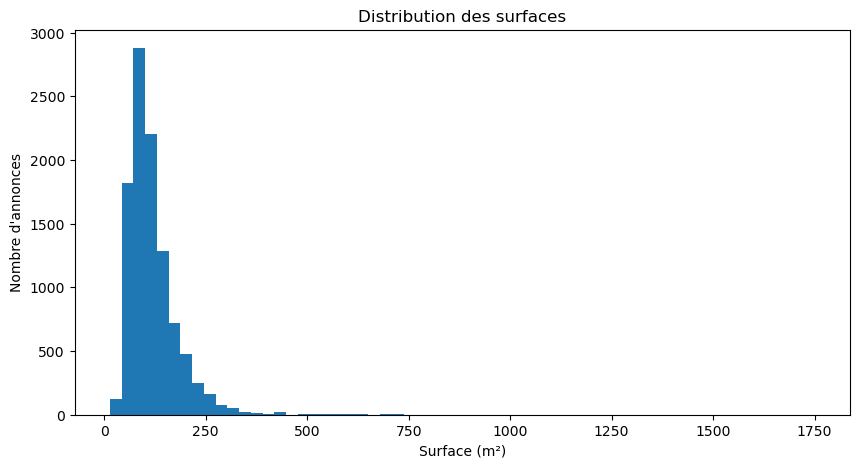

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(eda["surface_m2"].dropna(), bins=60)
plt.title("Distribution des surfaces")
plt.xlabel("Surface (m²)")
plt.ylabel("Nombre d'annonces")
plt.show()

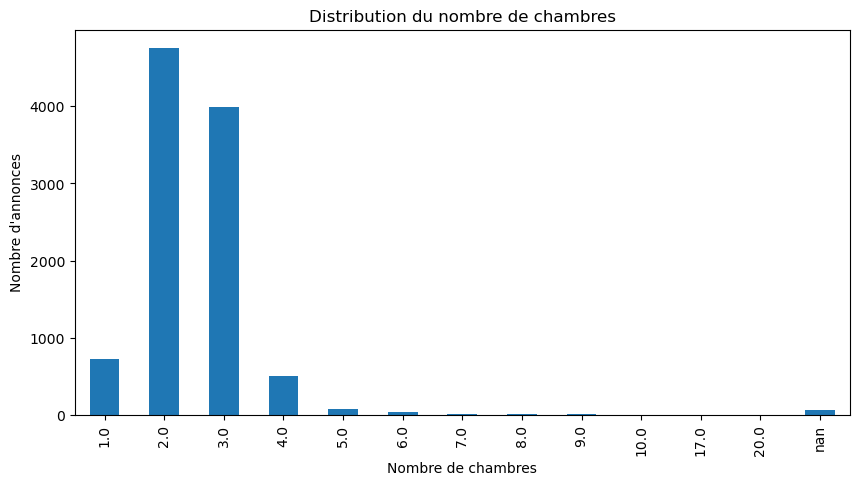

In [32]:
bedroom_counts = eda["bedrooms"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(10, 5))
bedroom_counts.plot(kind="bar")
plt.title("Distribution du nombre de chambres")
plt.xlabel("Nombre de chambres")
plt.ylabel("Nombre d'annonces")
plt.show()

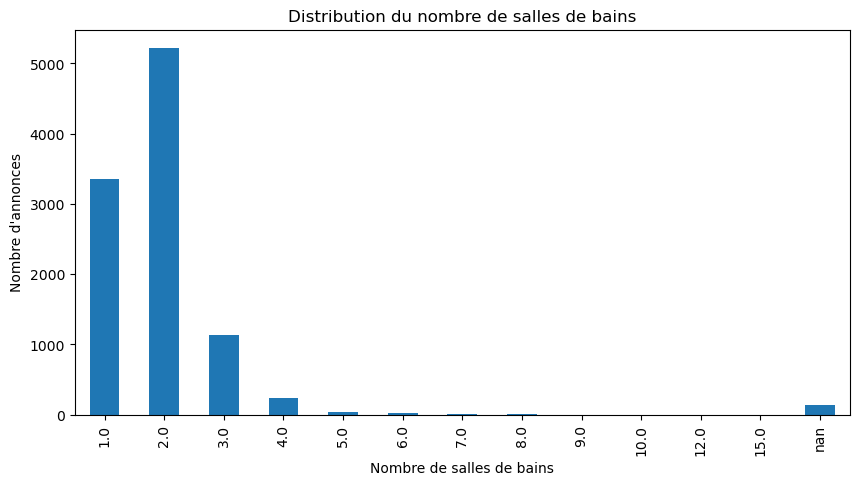

In [33]:
bathroom_counts = eda["bathrooms"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(10, 5))
bathroom_counts.plot(kind="bar")
plt.title("Distribution du nombre de salles de bains")
plt.xlabel("Nombre de salles de bains")
plt.ylabel("Nombre d'annonces")
plt.show()

In [34]:
physical_consistency = eda[
    ["surface_m2", "bedrooms", "bathrooms", "property_type"]
].copy()

physical_consistency["m2_per_bedroom"] = (
    physical_consistency["surface_m2"] / physical_consistency["bedrooms"]
)

physical_consistency[
    ["surface_m2", "bedrooms", "bathrooms", "m2_per_bedroom"]
].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
surface_m2,10158.0,119.100118,70.180571,14.0,42.0,52.000000,104.0,232.0,340.000,1750.0
bedrooms,10099.0,2.471235,0.824486,1.0,1.0,1.000000,2.0,4.0,5.000,20.0
bathrooms,10026.0,1.856573,0.815422,1.0,1.0,1.000000,2.0,3.0,4.000,15.0
m2_per_bedroom,10099.0,48.481587,21.340006,9.0,20.5,26.666667,45.0,81.0,110.502,631.5


#### Conclusion — Caractéristiques physiques

L'analyse des caractéristiques physiques montre que la majorité des biens possède une structure relativement homogène, mais que certaines valeurs extrêmes nécessitent une étude plus approfondie.

La surface médiane est de **105 m²**, tandis que la moyenne atteint environ **119,6 m²**, ce qui indique une légère asymétrie vers les grandes surfaces. La moitié centrale des annonces se situe entre **79 et 142 m²**, 95 % des biens restent sous **234 m²** et 99 % sous environ **343 m²**.

La valeur maximale de **2 200 m²** est très éloignée du reste de la distribution. Elle ne sera toutefois pas supprimée automatiquement, car elle peut correspondre à un bien atypique ou à un type de propriété particulier.

Le nombre de chambres est fortement concentré autour de **2 et 3 chambres**. Le nombre médian est de 2, et 99 % des annonces possèdent au maximum 5 chambres. Une valeur maximale de 20 chambres constitue donc une observation très atypique.

Une situation similaire est observée pour les salles de bains : la majorité des biens en possède 1 ou 2, tandis que 99 % en ont au maximum 4. La valeur maximale de 15 devra être analysée avec le type et la surface du bien.

Le ratio `m2_per_bedroom` présente une médiane d'environ **45 m² par chambre**. Les valeurs très élevées de ce ratio peuvent signaler des propriétés particulières, des types de biens pour lesquels le nombre de chambres est peu pertinent ou des observations nécessitant une vérification supplémentaire.

Les valeurs manquantes restent faibles pour `bedrooms` et `bathrooms`. Elles ne seront pas imputées à ce stade afin d'éviter d'introduire artificiellement des informations, notamment pour les types de biens où ces caractéristiques peuvent ne pas être applicables.

**Décisions pour la suite :**
- conserver les valeurs extrêmes pour une analyse croisée avec `property_type`, `city` et le prix ;
- ne pas appliquer de suppression automatique basée uniquement sur la surface ou le nombre de pièces ;
- conserver `surface_m2`, `bedrooms` et `bathrooms` comme variables candidates importantes ;
- traiter les valeurs manquantes plus tard dans le pipeline de prétraitement ;
- vérifier dans l'analyse bivariée si la relation entre surface, nombre de pièces et prix est linéaire ou non.

### 4.3 Analyse du prix au m²

Le prix au m² permet de comparer des biens de tailles différentes. Il est utilisé ici uniquement pour l'analyse exploratoire et ne devra pas être utilisé comme variable prédictive directe de `price_mad`.

In [35]:
eda["price_per_m2"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count     10158.000000
mean      16051.635992
std        9788.277358
min        1000.000000
1%         4129.748100
5%         6152.201500
25%       10307.690000
50%       14412.445000
75%       19402.990000
90%       25000.000000
95%       29429.304000
99%       55679.213400
max      149038.460000
Name: price_per_m2, dtype: float64

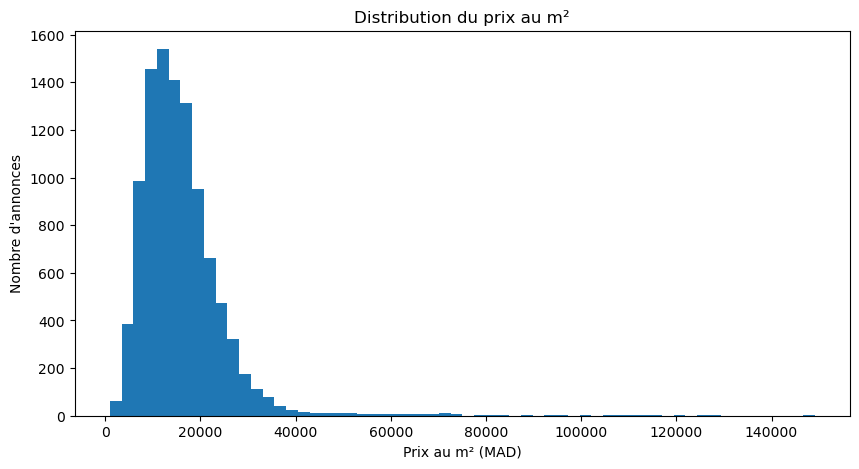

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(eda["price_per_m2"].dropna(), bins=60)
plt.title("Distribution du prix au m²")
plt.xlabel("Prix au m² (MAD)")
plt.ylabel("Nombre d'annonces")
plt.show()

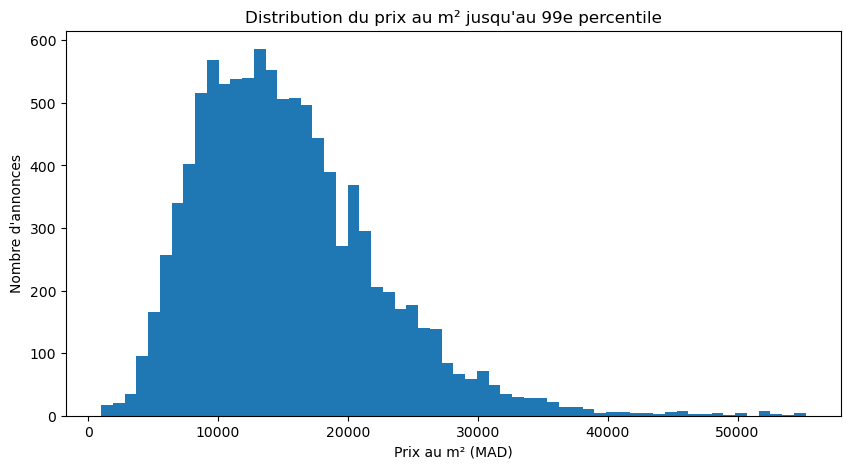

In [37]:
p99_m2 = eda["price_per_m2"].quantile(0.99)
price_m2_trimmed = eda.loc[eda["price_per_m2"] <= p99_m2, "price_per_m2"]

plt.figure(figsize=(10, 5))
plt.hist(price_m2_trimmed.dropna(), bins=60)
plt.title("Distribution du prix au m² jusqu'au 99e percentile")
plt.xlabel("Prix au m² (MAD)")
plt.ylabel("Nombre d'annonces")
plt.show()

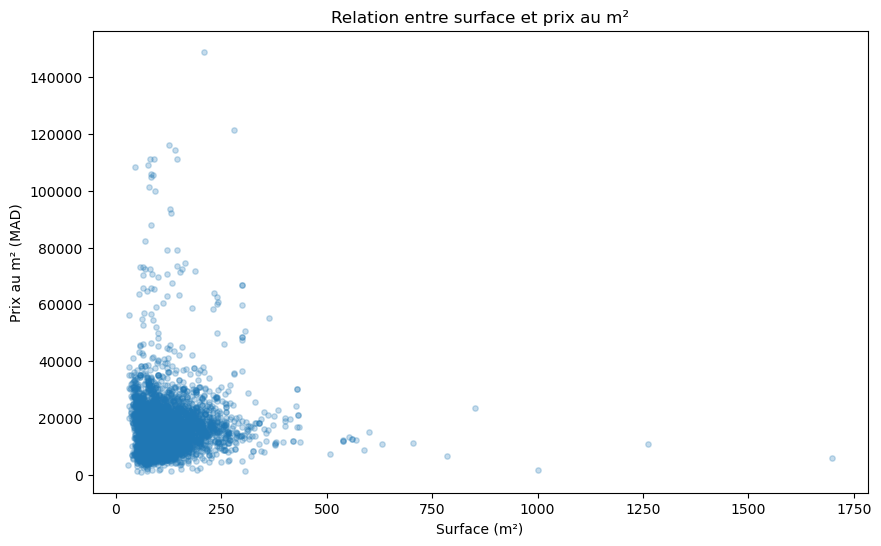

In [38]:
sample_scatter = eda[["surface_m2", "price_per_m2"]].dropna()

if len(sample_scatter) > 5000:
    sample_scatter = sample_scatter.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_scatter["surface_m2"], sample_scatter["price_per_m2"], alpha=0.25, s=15)
plt.title("Relation entre surface et prix au m²")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix au m² (MAD)")
plt.show()

#### Conclusion — Analyse du prix au m²

Le prix au m² présente une distribution fortement asymétrique, avec une médiane de **14 500 MAD/m²** et une moyenne d'environ **16 058 MAD/m²**.

La moitié centrale des annonces se situe approximativement entre **10 462 et 19 420 MAD/m²**. Environ 90 % des biens restent sous **25 000 MAD/m²**, 95 % sous **29 074 MAD/m²**, tandis que le 99e percentile atteint déjà environ **52 383 MAD/m²**.

La valeur maximale, proche de **149 038 MAD/m²**, montre l'existence d'une queue supérieure importante. Ces valeurs très élevées ne seront pas supprimées automatiquement : elles devront être analysées conjointement avec la ville, le quartier, le type de bien et la surface.

Le nuage de points entre `surface_m2` et `price_per_m2` montre également que les prix au m² les plus élevés apparaissent principalement parmi les petites et moyennes surfaces, tandis que les très grandes surfaces présentent généralement des valeurs au m² plus faibles.

Cette observation suggère que la relation entre surface et valeur immobilière n'est probablement pas strictement linéaire. Elle devra être étudiée plus précisément lors des analyses bivariées et multivariées, car l'effet observé peut également dépendre de la localisation et du type de propriété.

`price_per_m2` constitue donc une variable très utile pour comprendre et comparer les différents segments du marché immobilier. Cependant, elle ne sera **pas utilisée comme variable prédictive de `price_mad`**, puisqu'elle est directement calculée à partir du prix et provoquerait une fuite de données.

**Décisions pour la suite :**
- analyser les prix au m² par ville, quartier et type de bien ;
- étudier les observations situées dans la partie supérieure de la distribution plutôt que de les supprimer automatiquement ;
- vérifier l'existence d'une relation non linéaire entre surface et prix ;
- considérer ultérieurement des transformations ou représentations non linéaires de la surface ;
- conserver `price_per_m2` uniquement comme variable d'analyse et de contrôle, jamais comme feature directe du modèle de prix.

### 4.4 Analyse géographique

La localisation est un facteur majeur du marché immobilier. Cette partie étudie la représentation des régions et des villes, puis les différences de prix au m² entre les zones géographiques.

In [39]:
region_distribution = eda["region"].value_counts().to_frame("nombre_annonces")
region_distribution["pourcentage"] = (
    region_distribution["nombre_annonces"] / len(eda) * 100
).round(2)

region_distribution

,nombre_annonces,pourcentage
region,,
Casablanca-Settat,5401,53.17
Marrakech-Safi,1955,19.25
Tanger-Tétouan-Al Hoceïma,1106,10.89
Rabat-Salé-Kénitra,806,7.93
Fès-Meknès,429,4.22
Souss-Massa,361,3.55
L'Oriental,67,0.66
Béni Mellal-Khénifra,30,0.3
Laâyoune-Sakia El Hamra,2,0.02


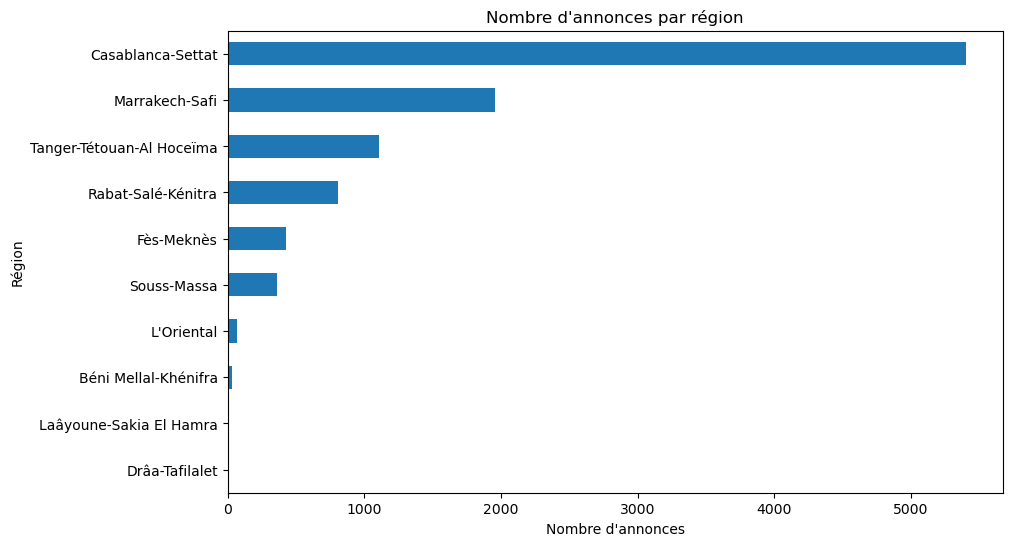

In [40]:
plt.figure(figsize=(10, 6))
eda["region"].value_counts().sort_values().plot(kind="barh")
plt.title("Nombre d'annonces par région")
plt.xlabel("Nombre d'annonces")
plt.ylabel("Région")
plt.show()

In [41]:
city_distribution = eda["city"].value_counts().to_frame("nombre_annonces")
city_distribution["pourcentage"] = (
    city_distribution["nombre_annonces"] / len(eda) * 100
).round(2)

city_distribution.head(15)

,nombre_annonces,pourcentage
city,,
Casablanca,4914,48.38
Marrakech,1891,18.62
Tanger,969,9.54
Agadir,357,3.51
Rabat,307,3.02
Fès,240,2.36
Meknès,188,1.85
Mohammedia,185,1.82
Kénitra,183,1.8


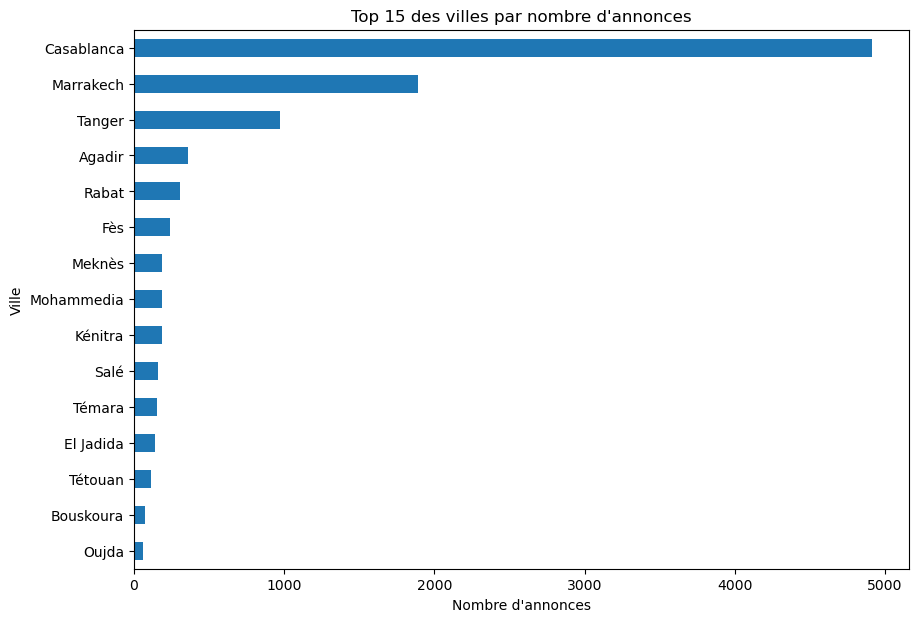

In [42]:
plt.figure(figsize=(10, 7))
eda["city"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 des villes par nombre d'annonces")
plt.xlabel("Nombre d'annonces")
plt.ylabel("Ville")
plt.show()

In [43]:
city_price = (
    eda.groupby("city")
    .agg(
        n=("listing_id", "size"),
        median_price=("price_mad", "median"),
        median_price_m2=("price_per_m2", "median"),
        q25_price_m2=("price_per_m2", lambda x: x.quantile(0.25)),
        q75_price_m2=("price_per_m2", lambda x: x.quantile(0.75))
    )
    .sort_values("n", ascending=False)
)

city_price.head(15)

,n,median_price,median_price_m2,q25_price_m2,q75_price_m2
city,,,,,
Casablanca,4914,1700000.0,14602.020,11590.1100,18404.9100
Marrakech,1891,1550000.0,18691.590,13759.0600,23574.3350
Tanger,969,1750000.0,15670.730,11111.1100,21452.1500
Agadir,357,1155000.0,12745.100,10714.2900,16000.0000
Rabat,307,3300000.0,21348.310,16902.9900,25243.0850
Fès,240,677500.0,5701.455,4868.2150,7059.2925
Meknès,188,650000.0,6225.000,5072.6850,7269.8450
Mohammedia,185,950000.0,10692.310,8764.0400,14000.0000
Kénitra,183,800000.0,8380.950,6846.9800,9572.7250


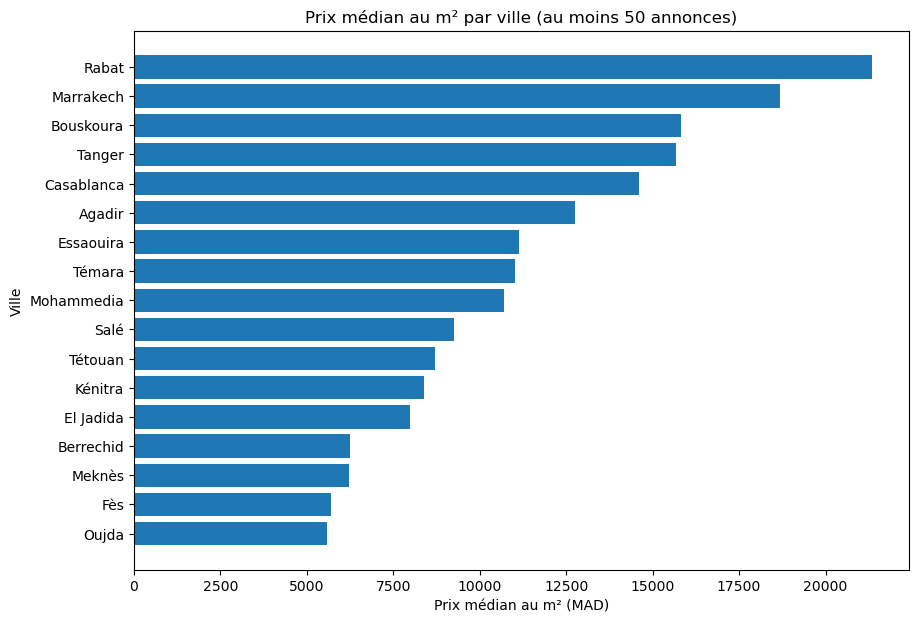

In [44]:
city_price_reliable = city_price[city_price["n"] >= 50].sort_values("median_price_m2")

plt.figure(figsize=(10, 7))
plt.barh(city_price_reliable.index, city_price_reliable["median_price_m2"])
plt.title("Prix médian au m² par ville (au moins 50 annonces)")
plt.xlabel("Prix médian au m² (MAD)")
plt.ylabel("Ville")
plt.show()

In [45]:
neighborhood_counts = eda["neighborhood"].value_counts(dropna=True)

neighborhood_frequency_summary = pd.Series({
    "quartiers_total": neighborhood_counts.size,
    "1_annonce": (neighborhood_counts == 1).sum(),
    "moins_de_5": (neighborhood_counts < 5).sum(),
    "moins_de_10": (neighborhood_counts < 10).sum(),
    "au_moins_10": (neighborhood_counts >= 10).sum(),
    "au_moins_30": (neighborhood_counts >= 30).sum()
})

neighborhood_frequency_summary.to_frame("nombre")

,nombre
quartiers_total,603
1_annonce,195
moins_de_5,341
moins_de_10,426
au_moins_10,177
au_moins_30,66


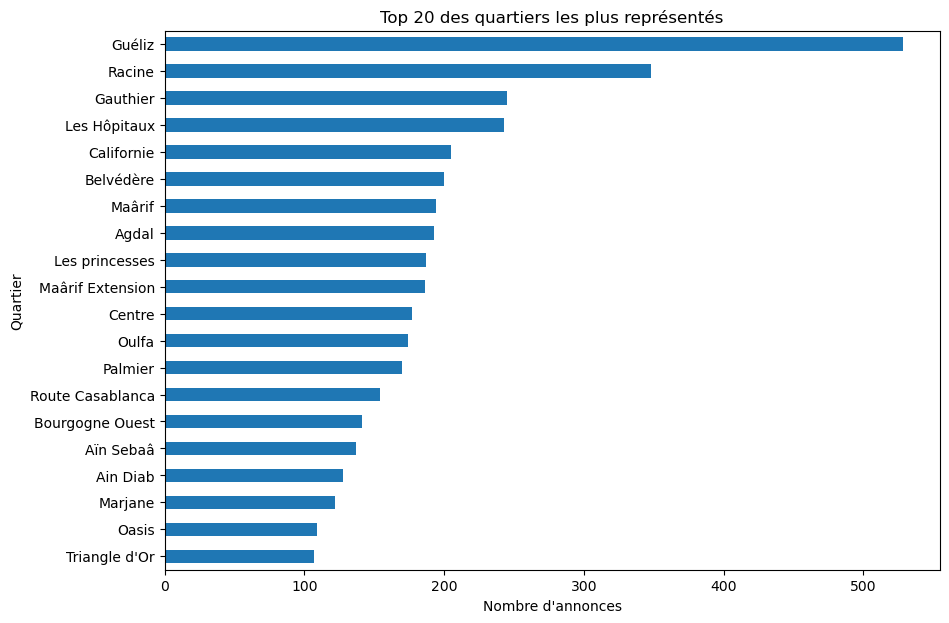

In [46]:
plt.figure(figsize=(10, 7))
neighborhood_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 des quartiers les plus représentés")
plt.xlabel("Nombre d'annonces")
plt.ylabel("Quartier")
plt.show()

#### Conclusion — Analyse géographique

L'analyse géographique révèle un **déséquilibre important dans la représentation du marché immobilier**.

La région Casablanca-Settat représente à elle seule **54,5 %** des annonces, suivie de Marrakech-Safi (**18,9 %**) et Tanger-Tétouan-Al Hoceïma (**10,53 %**). Ces trois régions regroupent ainsi près de **84 % du dataset**.

La concentration est encore plus forte au niveau des villes : Casablanca représente **50,07 %** des observations, Marrakech **18,26 %** et Tanger **9,27 %**. À elles seules, ces trois villes constituent environ **77,6 % des données**.

Certaines régions sont au contraire très faiblement représentées, notamment Laâyoune-Sakia El Hamra et Drâa-Tafilalet. La couverture géographique du dataset ne peut donc pas être considérée comme parfaitement représentative de l'ensemble du marché marocain.

L'analyse du prix médian au m² confirme également une forte hétérogénéité géographique. Parmi les villes suffisamment représentées, Rabat présente un prix médian d'environ **21 342 MAD/m²**, Marrakech **18 599 MAD/m²**, Tanger **15 429 MAD/m²** et Casablanca **14 682 MAD/m²**, tandis que certaines villes comme Fès, Meknès ou Oujda présentent des niveaux nettement plus faibles.

Ces différences confirment que la **localisation constitue une variable essentielle pour l'estimation immobilière**. Elles doivent toutefois être interprétées avec prudence, car les villes ne possèdent pas les mêmes tailles d'échantillon ni nécessairement la même composition en termes de surfaces, quartiers et types de biens.

L'analyse des quartiers met en évidence une autre difficulté : parmi les **646 quartiers représentés**, environ **30 % n'apparaissent qu'une seule fois**, près de **55 % ont moins de 5 annonces** et environ **69 % ont moins de 10 observations**. Le quartier est donc potentiellement très informatif, mais il constitue également une variable catégorielle à forte cardinalité contenant de nombreuses catégories rares.

**Décisions pour la suite :**
- conserver `region`, `city` et `neighborhood` comme variables candidates majeures ;
- ne pas interpréter les performances globales du futur modèle sans examiner également les performances par ville ;
- éviter une confiance excessive dans les régions et villes très faiblement représentées ;
- traiter les quartiers rares lors du preprocessing, par regroupement ou encodage adapté ;
- éviter un One-Hot Encoding naïf de tous les quartiers sans contrôle de la cardinalité ;
- envisager un encodage adapté aux variables géographiques, réalisé uniquement sur les données d'entraînement afin d'éviter toute fuite de cible ;
- tenir compte de la dépendance spatiale lors de la séparation train/test et de la validation du modèle ;
- analyser ensuite les interactions entre localisation, type de bien, surface et prix.

Cette analyse confirme que MaisonDeLUX ne doit pas apprendre un prix immobilier « national moyen », mais plusieurs **sous-marchés géographiques présentant des structures de prix différentes**.

### 4.5 Analyse des types de biens

Les différentes catégories immobilières peuvent présenter des structures de prix et de surface très différentes. Nous vérifions également si certaines catégories sont trop rares pour être apprises correctement par un modèle.

In [47]:
property_distribution = eda["property_type"].value_counts(dropna=False).to_frame("nombre_annonces")
property_distribution["pourcentage"] = (
    property_distribution["nombre_annonces"] / len(eda) * 100
).round(2)

property_distribution

,nombre_annonces,pourcentage
property_type,,
appartement,8916,87.77
unknown,953,9.38
studio,160,1.58
duplex,78,0.77
immeuble,28,0.28
villa,9,0.09
riad,7,0.07
maison,5,0.05
bureau,1,0.01


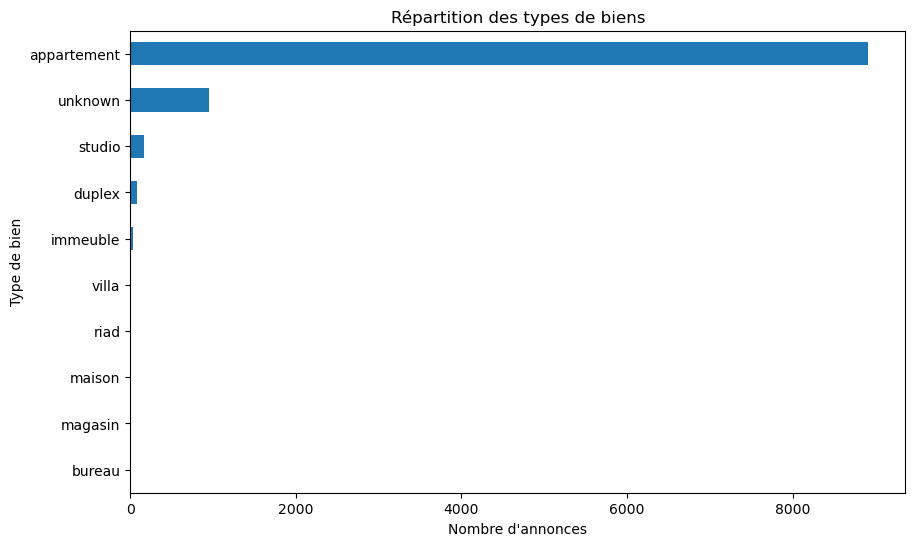

In [48]:
plt.figure(figsize=(10, 6))
eda["property_type"].value_counts().sort_values().plot(kind="barh")
plt.title("Répartition des types de biens")
plt.xlabel("Nombre d'annonces")
plt.ylabel("Type de bien")
plt.show()

In [49]:
property_stats = (
    eda.groupby("property_type")
    .agg(
        n=("listing_id", "size"),
        median_surface=("surface_m2", "median"),
        median_price=("price_mad", "median"),
        median_price_m2=("price_per_m2", "median")
    )
    .sort_values("n", ascending=False)
)

property_stats

,n,median_surface,median_price,median_price_m2
property_type,,,,
appartement,8916,105.0,1500000.0,14057.165
unknown,953,101.0,1600000.0,16239.040
studio,160,50.0,1250000.0,23876.265
duplex,78,178.0,2850000.0,16338.235
immeuble,28,216.5,3225000.0,14520.755
villa,9,303.0,4250000.0,11315.790
riad,7,117.0,4600000.0,30000.000
maison,5,86.0,1100000.0,10617.230
bureau,1,119.0,2590000.0,21764.710


#### Conclusion — Analyse des types de biens

L'analyse met en évidence un **déséquilibre très important entre les types de propriétés**.

Les appartements représentent **88,04 % du dataset**, avec 11 918 observations, tandis que la catégorie `unknown` représente 9,21 %. Les autres catégories sont beaucoup moins représentées : 202 studios, 107 duplexes, puis seulement quelques dizaines ou quelques unités pour les immeubles, villas, riads, maisons, bureaux et magasins.

Cette distribution ne doit pas être interprétée comme la structure réelle du marché immobilier marocain. Elle reflète également la manière dont les données ont été collectées et constitue donc un biais d'échantillonnage important.

Les différences de prix montrent cependant que le type de bien apporte une information pertinente. Un appartement possède une surface médiane de **105 m²** et un prix médian d'environ **1,5 M MAD**, tandis qu'un studio possède une surface médiane de seulement **50 m²**, mais un prix médian au m² beaucoup plus élevé, proche de **23 541 MAD/m²**.

Les duplexes présentent une surface médiane de **186 m²** et un prix médian de **2,8 M MAD**, tandis que les villas atteignent une surface médiane de **320 m²** et un prix médian de **4,3 M MAD**. Malgré leur prix total élevé, leur prix médian au m² est plus faible, ce qui confirme que la relation entre surface et valeur immobilière dépend également du type de bien.

Les résultats des catégories très rares doivent cependant être interprétés avec prudence. Par exemple, les valeurs observées pour les riads, bureaux ou magasins reposent sur un nombre trop faible d'observations pour représenter de manière fiable ces marchés.

La catégorie `unknown`, qui contient encore **1 247 observations**, ne sera pas automatiquement assimilée aux appartements. Elle sera conservée séparément jusqu'à ce que les analyses suivantes permettent de mieux comprendre sa composition.

**Décisions pour la suite :**
- conserver `property_type` comme variable explicative importante ;
- ne pas considérer la distribution actuelle des types comme représentative du marché marocain global ;
- conserver temporairement la catégorie `unknown` au lieu de l'imputer arbitrairement ;
- éviter de tirer des conclusions fortes sur les catégories disposant de très peu d'observations ;
- évaluer les performances du futur modèle par type de bien, et pas uniquement avec une métrique globale ;
- étudier les interactions entre `property_type`, localisation, surface et prix ;
- tester ultérieurement si un modèle global suffit ou si certains segments immobiliers nécessitent une modélisation spécifique.

Le futur modèle risque naturellement d'être plus performant sur les appartements, qui constituent la grande majorité des données. Cette limite devra être explicitement prise en compte lors de l'évaluation de MaisonDeLUX V1.

### 4.6 Analyse des équipements

Les variables `parking`, `balcony`, `sea_view` et `furnished_status` peuvent contenir une information utile, mais une forte proportion de valeurs `unknown` peut également refléter la qualité de la collecte plutôt qu'une caractéristique réelle du bien.

In [50]:
amenity_cols = ["parking", "balcony", "sea_view", "furnished_status"]

amenity_summary = []
for col in amenity_cols:
    counts = eda[col].value_counts(dropna=False)
    unknown_rate = (eda[col].astype("string").str.lower() == "unknown").mean() * 100
    amenity_summary.append({
        "variable": col,
        "modalites": counts.to_dict(),
        "unknown_pct": round(unknown_rate, 2)
    })

pd.DataFrame(amenity_summary)

,variable,modalites,unknown_pct
0,parking,"{'unknown': 8304, 'yes': 1854}",81.75
1,balcony,"{'unknown': 8827, 'yes': 1331}",86.90
2,sea_view,"{'unknown': 9961, 'yes': 197}",98.06
3,furnished_status,"{'unknown': 8665, 'furnished': 1470, 'unfurnis...",85.30


In [51]:
for col in amenity_cols:
    print(f"\n--- {col} ---")
    display(
        eda.groupby(col, dropna=False)
        .agg(
            n=("listing_id", "size"),
            median_price=("price_mad", "median"),
            median_price_m2=("price_per_m2", "median")
        )
        .sort_values("n", ascending=False)
    )


--- parking ---


,n,median_price,median_price_m2
parking,,,
unknown,8304,1400000.0,13744.920
yes,1854,1900000.0,16865.145



--- balcony ---


,n,median_price,median_price_m2
balcony,,,
unknown,8827,1420000.0,13975.16
yes,1331,2000000.0,17012.99



--- sea_view ---


,n,median_price,median_price_m2
sea_view,,,
unknown,9961,1500000.0,14285.71
yes,197,2999000.0,23000.00



--- furnished_status ---


,n,median_price,median_price_m2
furnished_status,,,
unknown,8665,1450000.0,14071.430
furnished,1470,1730000.0,16124.625
unfurnished,23,1350000.0,13100.000


In [52]:
amenity_unknown_by_batch = pd.DataFrame(index=sorted(eda["batch_id"].dropna().unique()))

for col in amenity_cols:
    amenity_unknown_by_batch[col + "_unknown_pct"] = (
        eda.assign(_unknown=eda[col].astype("string").str.lower().eq("unknown"))
        .groupby("batch_id")["_unknown"]
        .mean()
        .mul(100)
        .round(2)
    )

amenity_unknown_by_batch

,parking_unknown_pct,balcony_unknown_pct,sea_view_unknown_pct,furnished_status_unknown_pct
git_head_complete,99.2,99.86,98.78,95.68
recovery_dangling_v3,65.15,83.33,92.42,83.33
recovery_misplaced_notebook,25.86,45.14,95.89,51.84


#### Conclusion — Analyse des équipements

L'analyse des équipements révèle une limitation importante de la qualité des données.

Les taux de valeurs `unknown` sont très élevés : **80,73 % pour le parking**, **86,39 % pour le balcon**, **98,05 % pour la vue sur mer** et **84,93 % pour le statut meublé**.

Il est essentiel de ne pas interpréter `unknown` comme l'absence de l'équipement. Pour plusieurs variables, les données distinguent principalement `yes` et `unknown`, et non `yes` et `no`. Une valeur inconnue signifie donc simplement que l'information n'a pas pu être confirmée.

Les annonces pour lesquelles un équipement est explicitement identifié présentent néanmoins des prix plus élevés. Par exemple, les biens avec parking ont un prix médian d'environ **1,9 M MAD**, ceux avec balcon **2,0 M MAD**, et ceux avec vue sur mer environ **2,95 M MAD**. La même tendance apparaît pour le prix au m².

Ces écarts ne permettent toutefois pas d'établir une relation causale directe. Les équipements peuvent être associés à d'autres facteurs tels que la localisation, le standing, la surface ou le type de bien.

L'analyse par lot de collecte met surtout en évidence un **effet de batch très important**. Le taux de parking inconnu varie par exemple d'environ **99 % à 26 %** selon le lot de collecte. Des écarts similaires apparaissent pour le balcon et le statut meublé.

Cela indique que l'absence d'information sur les équipements n'est pas aléatoire : elle dépend en grande partie de la manière dont les données ont été collectées. Ces variables peuvent donc contenir à la fois une information immobilière réelle et une information liée au processus de scraping.

**Décisions pour la suite :**
- ne jamais convertir `unknown` en `no` ;
- conserver provisoirement les équipements comme variables catégorielles ;
- interpréter avec prudence les différences de prix observées ;
- vérifier leurs interactions avec la ville, le type de bien et la surface ;
- comparer ultérieurement les performances des modèles avec et sans ces variables ;
- éviter d'utiliser `batch_id` comme caractéristique prédictive du prix, car il représente un artefact de collecte ;
- envisager, dans une version future du projet, une extraction plus homogène des équipements à partir des descriptions ou de sources mieux structurées.

Les équipements semblent donc potentiellement informatifs, mais leur forte dépendance au processus de collecte impose une validation supplémentaire avant leur utilisation définitive dans le modèle.

### 4.7 Analyse bivariée

Cette partie étudie les relations entre le prix et les principales caractéristiques numériques. Les corrélations de Pearson et de Spearman sont comparées afin de distinguer les relations linéaires des relations simplement monotones.

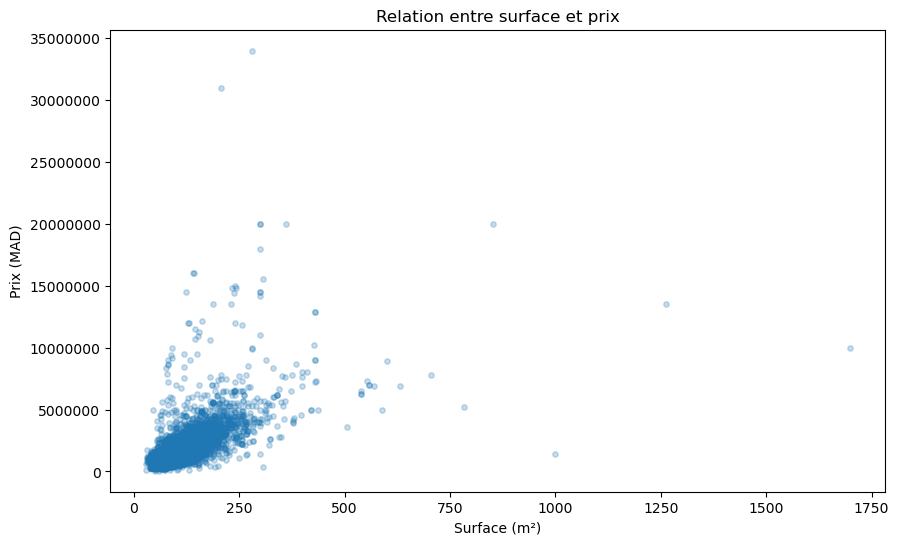

In [53]:
scatter_price_surface = eda[["surface_m2", "price_mad"]].dropna()

if len(scatter_price_surface) > 5000:
    scatter_price_surface = scatter_price_surface.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(scatter_price_surface["surface_m2"], scatter_price_surface["price_mad"], alpha=0.25, s=15)
plt.title("Relation entre surface et prix")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix (MAD)")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [54]:
numeric_for_corr = ["price_mad", "surface_m2", "bedrooms", "bathrooms"]

pearson_corr = eda[numeric_for_corr].corr(method="pearson")
spearman_corr = eda[numeric_for_corr].corr(method="spearman")

print("Corrélation de Pearson")
display(pearson_corr.round(3))

print("Corrélation de Spearman")
display(spearman_corr.round(3))

Corrélation de Pearson


,price_mad,surface_m2,bedrooms,bathrooms
price_mad,1.000,0.636,0.364,0.433
surface_m2,0.636,1.000,0.570,0.551
bedrooms,0.364,0.570,1.000,0.542
bathrooms,0.433,0.551,0.542,1.000


Corrélation de Spearman


,price_mad,surface_m2,bedrooms,bathrooms
price_mad,1.000,0.700,0.395,0.537
surface_m2,0.700,1.000,0.663,0.637
bedrooms,0.395,0.663,1.000,0.513
bathrooms,0.537,0.637,0.513,1.000


In [55]:
surface_bins = pd.qcut(eda["surface_m2"], q=10, duplicates="drop")

surface_price_bins = (
    eda.assign(surface_bin=surface_bins)
    .groupby("surface_bin", observed=True)
    .agg(
        n=("listing_id", "size"),
        median_surface=("surface_m2", "median"),
        median_price=("price_mad", "median"),
        median_price_m2=("price_per_m2", "median")
    )
)

surface_price_bins

,n,median_surface,median_price,median_price_m2
surface_bin,,,,
"(13.999, 59.0]",1020,52.0,900000.0,19047.620
"(59.0, 73.0]",1064,67.0,750000.0,11333.995
"(73.0, 83.0]",976,79.0,1040000.0,13284.420
"(83.0, 93.0]",1022,89.0,1200000.0,13491.575
"(93.0, 104.0]",1006,99.0,1420000.0,14218.665
"(104.0, 117.0]",1010,110.0,1560000.0,14272.485
"(117.0, 130.0]",1031,124.0,1750000.0,14000.000
"(130.0, 153.0]",1017,141.0,2000000.0,14482.760
"(153.0, 193.0]",1003,170.0,2722500.0,16101.690


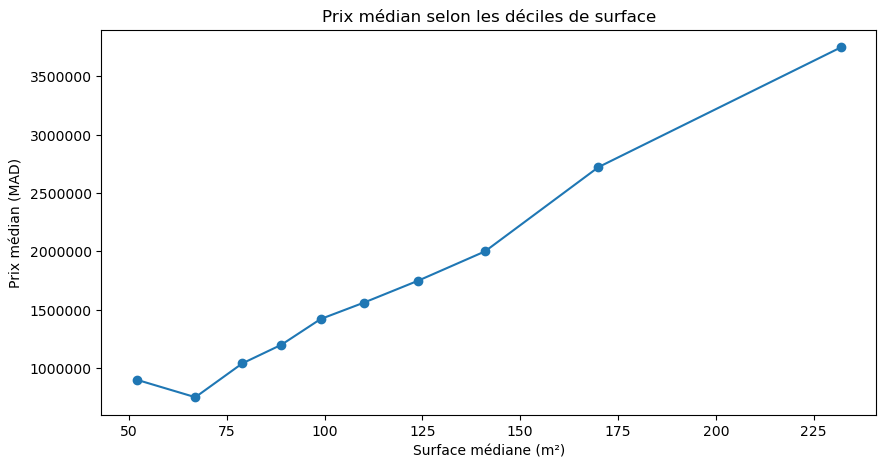

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(surface_price_bins["median_surface"], surface_price_bins["median_price"], marker="o")
plt.title("Prix médian selon les déciles de surface")
plt.xlabel("Surface médiane (m²)")
plt.ylabel("Prix médian (MAD)")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### Conclusion — Analyse bivariée

L'analyse bivariée confirme que la **surface constitue actuellement la variable numérique la plus fortement associée au prix**.

La corrélation de Pearson entre `surface_m2` et `price_mad` atteint **0,637**, tandis que la corrélation de Spearman atteint **0,703**. Le fait que la corrélation de Spearman soit plus élevée indique que la relation entre surface et prix est fortement monotone, mais probablement **non strictement linéaire**.

Le nuage de points montre également que la dispersion des prix augmente lorsque la surface devient plus importante. Deux biens de grande taille peuvent ainsi présenter des prix très différents, probablement en raison d'autres facteurs tels que la localisation, le type de propriété ou le niveau de standing. Cette variation suggère la présence d'une possible hétéroscédasticité.

Les variables `bedrooms` et `bathrooms` sont également associées au prix, mais de manière moins forte. Le nombre de salles de bains présente une relation plus importante avec le prix que le nombre de chambres, avec une corrélation de Spearman de **0,539**, contre **0,397** pour les chambres.

Les caractéristiques physiques sont également corrélées entre elles : la surface est liée au nombre de chambres et de salles de bains. Cette dépendance devra être prise en compte notamment lors de l'utilisation de modèles linéaires afin de vérifier un éventuel problème de multicolinéarité.

L'analyse par déciles de surface confirme une augmentation nette du prix médian à mesure que la surface augmente. À partir d'environ 80 m², le prix médian progresse régulièrement jusqu'à atteindre environ **3,8 M MAD** pour les biens dont la surface médiane est proche de 234 m².

Une exception apparaît toutefois parmi les plus petites surfaces : les biens autour de 52 m² présentent un prix médian supérieur à ceux autour de 67 m² et un prix au m² nettement plus élevé. Cette différence peut refléter un effet de composition lié aux studios, aux localisations premium ou à d'autres segments spécifiques.

Ces résultats montrent que la valeur immobilière dépend fortement de la surface, mais que son effet varie selon le segment du marché.

**Décisions pour la suite :**
- conserver `surface_m2` comme variable prédictive majeure ;
- conserver `bedrooms` et `bathrooms`, tout en tenant compte de leur dépendance avec la surface ;
- tester plus tard la multicolinéarité pour les modèles linéaires ;
- comparer les performances sur `price_mad` et `log(price_mad)` afin de réduire l'effet de l'asymétrie et de la dispersion croissante ;
- ne pas supposer une relation strictement linéaire entre surface et prix ;
- privilégier également des modèles capables d'apprendre des relations non linéaires et des interactions ;
- poursuivre l'analyse en croisant maintenant la surface, la localisation et le type de bien.

L'ensemble de ces résultats confirme que la surface explique une part importante du prix, mais qu'elle ne peut pas être interprétée indépendamment du contexte géographique et du type de propriété.

### 4.8 Analyse multivariée

Nous combinons plusieurs dimensions afin de vérifier si l'effet de la surface ou du type de bien dépend également de la localisation.

In [57]:
city_type_stats = (
    eda.groupby(["city", "property_type"])
    .agg(
        n=("listing_id", "size"),
        median_surface=("surface_m2", "median"),
        median_price=("price_mad", "median"),
        median_price_m2=("price_per_m2", "median")
    )
    .reset_index()
)

city_type_stats.sort_values(["city", "n"], ascending=[True, False]).head(40)

,city,property_type,n,median_surface,median_price,median_price_m2
0,Agadir,appartement,329,80.0,1170000.0,12923.080
4,Agadir,unknown,23,92.0,900000.0,12554.350
1,Agadir,duplex,3,98.0,1250000.0,14880.950
2,Agadir,immeuble,1,75.0,800000.0,10666.670
3,Agadir,studio,1,142.0,1350000.0,9507.040
5,Berrechid,appartement,58,90.0,620000.0,6467.390
6,Berrechid,unknown,3,64.0,300000.0,6000.000
7,Bouskoura,appartement,58,150.0,2770000.0,15655.105
9,Bouskoura,duplex,6,208.5,3600000.0,19146.965
11,Bouskoura,unknown,6,398.5,4450000.0,11936.790


In [58]:
top_cities = eda["city"].value_counts().head(5).index
subset_top = eda[eda["city"].isin(top_cities)].copy()

subset_top["surface_class"] = pd.cut(
    subset_top["surface_m2"],
    bins=[0, 60, 100, 150, 250, np.inf],
    labels=["≤60", "61-100", "101-150", "151-250", ">250"]
)

top_city_surface = (
    subset_top.groupby(["city", "surface_class"], observed=True)
    .agg(
        n=("listing_id", "size"),
        median_price=("price_mad", "median"),
        median_price_m2=("price_per_m2", "median")
    )
)

top_city_surface

n  median_price  median_price_m2
city       surface_class                                     
Agadir     ≤60              65      650000.0        12000.000
           61-100          189     1047200.0        13066.670
           101-150          89     1600000.0        13500.000
           151-250          10     1647500.0         9544.970
           >250              4     6100000.0        13527.775
Casablanca ≤60             427     1080000.0        21666.670
           61-100         1307     1150000.0        13541.670
           101-150        1756     1750000.0        14173.230
           151-250        1177     2950000.0        16012.660
           >250            247     4600000.0        14189.190
Marrakech  ≤60             386     1025500.0        21103.240
           61-100          917     1500000.0        18674.700
           101-150         460     2125000.0        18333.330
           151-250         109     3000000.0        16500.000
           >250             19     4050000.0        11315.790
Rabat      ≤60               8     1150000.0        24494.945
           61-100           46     1700000.0        19593.365
           101-150          98     2400000.0        20777.025
           151-250         128     4200000.0        22420.810
           >250             27     6300000.0        20930.230
Tanger     ≤60              98      570000.0         9827.380
           61-100          378     1201750.0        14796.005
           101-150         307     2080000.0        17452.830
           151-250         155     2790000.0        15895.950
           >250             31     6000000.0        17187.500

#### Conclusion — Analyse multivariée

L'analyse multivariée confirme que le prix immobilier dépend fortement de l'interaction entre **localisation, surface et type de bien**.

Pour un même type de propriété, les niveaux de prix au m² varient fortement selon la ville. Par exemple, les appartements présentent un prix médian d'environ **5 736 MAD/m² à Fès**, contre **14 433 MAD/m² à Casablanca**.

À l'intérieur d'une même ville, le type de bien modifie également fortement la structure des prix. À Casablanca, les studios atteignent environ **24 000 MAD/m²**, contre environ **14 433 MAD/m²** pour les appartements.

L'effet de la surface varie également selon les villes : certains marchés présentent une prime importante pour les petites surfaces, tandis que d'autres montrent une évolution différente du prix au m² avec la taille du bien.

Ces résultats confirment donc l'existence de plusieurs **sous-marchés immobiliers** plutôt qu'une relation nationale unique.

Les catégories contenant très peu d'observations doivent toutefois être interprétées avec prudence.

**Décisions :**
- conserver `city`, `property_type` et `surface_m2` comme variables majeures ;
- privilégier des modèles capables d'apprendre des interactions et des relations non linéaires ;
- ne pas assimiler automatiquement `unknown` à `appartement` ;
- éviter de tirer des conclusions sur les segments très peu représentés ;
- évaluer ultérieurement les performances du modèle par ville et par type de bien.

### 4.9 Audit des biais potentiels

Cette étape vérifie si la structure du dataset peut introduire des biais : déséquilibre géographique, lots de collecte différents ou présence de doublons possibles.

In [59]:
batch_stats = (
    eda.groupby("batch_id", dropna=False)
    .agg(
        n=("listing_id", "size"),
        median_price=("price_mad", "median"),
        median_surface=("surface_m2", "median"),
        median_price_m2=("price_per_m2", "median"),
        outlier_rate=("outlier_decision", lambda x: (x != "not_flagged").mean() * 100)
    )
)

batch_stats["share_pct"] = (batch_stats["n"] / len(eda) * 100).round(2)
batch_stats["outlier_rate"] = batch_stats["outlier_rate"].round(2)

batch_stats

,n,median_price,median_surface,median_price_m2,outlier_rate,share_pct
batch_id,,,,,,
git_head_complete,7706,1400000.0,100.0,13668.195,1.38,75.86
recovery_dangling_v3,66,1480000.0,93.0,16803.965,1.52,0.65
recovery_misplaced_notebook,2386,1800000.0,114.5,16535.430,4.65,23.49


In [60]:
duplicate_sensitivity = (
    eda.assign(
        dataset_group=np.where(
            eda["duplicate_status_repaired"] == "unique",
            "unique",
            "possible_duplicate"
        )
    )
    .groupby("dataset_group")
    .agg(
        n=("listing_id", "size"),
        median_price=("price_mad", "median"),
        median_surface=("surface_m2", "median"),
        median_price_m2=("price_per_m2", "median")
    )
)

duplicate_sensitivity

,n,median_price,median_surface,median_price_m2
dataset_group,,,,
possible_duplicate,2093,1850000.0,120.0,15963.86
unique,8065,1400000.0,100.0,13888.89


In [61]:
possible_dup_share_by_city = (
    eda.assign(
        is_possible_duplicate=eda["duplicate_status_repaired"].eq("possible_duplicate")
    )
    .groupby("city")
    .agg(
        n=("listing_id", "size"),
        possible_duplicate_pct=("is_possible_duplicate", "mean")
    )
)

possible_dup_share_by_city["possible_duplicate_pct"] = (
    possible_dup_share_by_city["possible_duplicate_pct"] * 100
).round(2)

possible_dup_share_by_city.sort_values(
    "possible_duplicate_pct",
    ascending=False
).head(15)

,n,possible_duplicate_pct
city,,
Casablanca,4914,32.11
Essaouira,50,24.00
Agadir,357,16.53
Marrakech,1891,15.81
Khouribga,14,14.29
Meknès,188,9.04
El Jadida,141,7.09
Berrechid,61,6.56
Tanger,969,6.19


#### Conclusion — Audit des biais potentiels

L'analyse met en évidence deux sources importantes de biais : les **lots de collecte** et les **doublons possibles**.

Le lot principal représente 74,48 % du dataset, tandis que `recovery_misplaced_notebook` représente près de 25 % et présente des prix, surfaces et taux d'outliers plus élevés. Cette différence ne prouve pas une erreur de collecte, mais montre que les lots ne possèdent pas exactement la même composition.

Par ailleurs, les 3 455 doublons possibles présentent des prix et des surfaces médians plus élevés que les observations uniques. Ils sont également fortement concentrés dans certaines villes, notamment Casablanca.

Ils ne seront donc pas supprimés automatiquement, car cela pourrait modifier artificiellement la distribution du marché.

**Décisions :**
- ne jamais utiliser `batch_id` comme variable prédictive ;
- conserver les doublons possibles pour l'instant ;
- empêcher un même groupe de doublons d'apparaître à la fois dans le train et le test ;
- comparer ultérieurement les performances sur l'ensemble des données et sur les observations uniques uniquement ;
- vérifier si les différences entre batches s'expliquent par la ville, le type de bien ou un artefact de collecte.

Ces précautions permettront d'obtenir une évaluation du modèle plus réaliste et de limiter les risques de fuite de données.

### 4.10 Analyse approfondie des valeurs extrêmes

Les observations extrêmes ne sont pas supprimées automatiquement. Nous cherchons à distinguer les biens atypiques mais plausibles des observations qui méritent une vérification supplémentaire.

In [62]:
eda["outlier_decision"].value_counts(dropna=False).to_frame("nombre")

,nombre
outlier_decision,
not_flagged,9940
uncertain,187
valid_extreme,31


In [63]:
outlier_reason_counts = (
    eda.loc[eda["outlier_decision"] != "not_flagged", "outlier_reasons"]
    .fillna("non_precise")
    .value_counts()
)

outlier_reason_counts.to_frame("nombre")

,nombre
outlier_reasons,
price_per_m2_above_reference_p99,131
price_above_p99|price_per_m2_above_reference_p99,40
surface_extreme,31
price_above_p99,4
bathrooms_above_8,3
surface_extreme|price_above_p99,3
bedrooms_above_8,3
surface_extreme|price_above_p99|bedrooms_above_8|bathrooms_above_8,2
bedrooms_above_8|price_per_m2_above_reference_p99,1


In [64]:
outlier_sample = (
    eda.loc[
        eda["outlier_decision"].isin(["uncertain", "valid_extreme"]),
        [
            "city", "neighborhood", "property_type",
            "surface_m2", "bedrooms", "bathrooms",
            "price_mad", "price_per_m2",
            "outlier_decision", "outlier_reasons", "title_raw"
        ]
    ]
    .sort_values("price_per_m2", ascending=False)
)

outlier_sample.head(30)

,city,neighborhood,property_type,surface_m2,bedrooms,bathrooms,price_mad,price_per_m2,outlier_decision,outlier_reasons,title_raw
7728,Casablanca,Gauthier,appartement,208.0,3.0,3.0,31000000.0,149038.46,uncertain,price_above_p99|price_per_m2_above_reference_p99,Appartement dernier étage à la vente à Gauthie...
8975,Casablanca,Ain Borja,appartement,114.0,2.0,2.0,14500000.0,127192.98,uncertain,price_above_p99|price_per_m2_above_reference_p99,Appartement à vendre ain borja
1938,Casablanca,Quartier Bachkou,appartement,106.0,2.0,2.0,13400000.0,126415.09,uncertain,price_above_p99|price_per_m2_above_reference_p99,Appartement à vendre Bd Taddart
6179,Agadir,avenue al hamra,appartement,90.0,3.0,2.0,11300000.0,125555.56,uncertain,price_above_p99|price_per_m2_above_reference_p99,NaN
9883,Fès,Route de Meknes,unknown,280.0,1.0,2.0,34000000.0,121428.57,uncertain,price_above_p99|price_per_m2_above_reference_p99,Ma ville Fès dans le quartier Wadi Fès
3993,Tanger,Manar,appartement,29.0,2.0,2.0,3500000.0,120689.66,uncertain,price_per_m2_above_reference_p99,Joli appartement vue mer en vente à Mnar
6880,Agadir,Hay Mohammadi,appartement,60.0,2.0,1.0,7200000.0,120000.00,uncertain,price_per_m2_above_reference_p99,Appartement avendre à hay mohammadi
6142,Marrakech,Route Casablanca,appartement,125.0,3.0,2.0,14500000.0,116000.00,uncertain,price_above_p99|price_per_m2_above_reference_p99,Appartement à vendre 125 m² Sidi abbad Marrakech
146,Casablanca,Les Hôpitaux,studio,42.0,1.0,1.0,4840000.0,115238.10,uncertain,price_per_m2_above_reference_p99,NaN
6093,Casablanca,Les Hôpitaux,appartement,183.0,3.0,2.0,21000000.0,114754.10,uncertain,price_above_p99|price_per_m2_above_reference_p99,Appartement de luxe à vendre 183 m² à Casablanca


In [65]:
outlier_by_city = (
    eda.assign(flagged=eda["outlier_decision"].ne("not_flagged"))
    .groupby("city")
    .agg(
        n=("listing_id", "size"),
        flagged_count=("flagged", "sum"),
        flagged_pct=("flagged", "mean")
    )
)

outlier_by_city["flagged_pct"] = (outlier_by_city["flagged_pct"] * 100).round(2)

outlier_by_city.sort_values(
    ["flagged_pct", "n"],
    ascending=[False, False]
).head(15)

,n,flagged_count,flagged_pct
city,,,
Khouribga,14,3,21.43
Bouskoura,73,10,13.70
Larache,23,2,8.70
Bouznika,13,1,7.69
Safi,14,1,7.14
Béni Mellal,16,1,6.25
Salé,159,9,5.66
Agadir,357,18,5.04
Berrechid,61,2,3.28


#### Conclusion — Analyse des valeurs extrêmes

L'analyse montre que les valeurs extrêmes restent limitées : **97,98 %** des observations ne sont pas signalées, tandis que **233 observations (1,72 %)** sont considérées comme incertaines et **41 (0,30 %)** comme des extrêmes plausibles.

Certaines observations présentent toutefois des prix au m² très supérieurs aux niveaux habituels du marché. Elles peuvent correspondre à des biens de luxe, mais certaines peuvent également provenir d'erreurs de saisie ou de mise à l'échelle du prix.

Les taux d'outliers par ville doivent également être interprétés avec prudence lorsque le nombre d'annonces est faible.

**Décisions :**
- ne pas supprimer automatiquement les valeurs extrêmes ;
- conserver les `valid_extreme` ;
- vérifier les observations `uncertain` avec leur localisation, type, surface et données brutes ;
- tester plus tard la sensibilité du modèle avec et sans les observations incertaines ;
- privilégier une détection contextuelle plutôt qu'une règle globale basée uniquement sur l'IQR.

Les outliers représentent donc une faible partie du dataset, mais leur traitement peut avoir un impact important sur la qualité et la robustesse du futur modèle.

### 4.11 Synthèse de l'analyse exploratoire

L'analyse exploratoire montre que le marché immobilier représenté dans le dataset est **fortement hétérogène** et ne peut pas être modélisé comme un marché uniforme.

Le prix présente une forte asymétrie positive, avec quelques valeurs très élevées. La transformation logarithmique du prix produit une distribution plus équilibrée et devra donc être testée lors de la modélisation.

Parmi les variables numériques, `surface_m2` apparaît comme la caractéristique la plus fortement associée au prix. Cependant, les relations observées ne sont pas strictement linéaires et dépendent fortement du contexte géographique et du type de bien.

La localisation joue un rôle central : les niveaux de prix varient fortement entre les villes et les quartiers. Le dataset reste toutefois très concentré sur Casablanca, Marrakech et Tanger, ce qui implique un risque de biais géographique.

La variable `property_type` est également informative, mais les appartements représentent environ 88 % des données. Les performances futures du modèle devront donc être évaluées avec prudence pour les catégories rares.

Les équipements comme le parking, le balcon ou la vue sur mer semblent associés à des prix plus élevés, mais leur forte proportion de valeurs `unknown` et leur dépendance au lot de collecte empêchent de les considérer comme parfaitement fiables.

L'analyse a également identifié des doublons possibles, des différences entre lots de collecte et un faible nombre d'observations extrêmes. Ces éléments ne seront pas supprimés automatiquement, mais devront être pris en compte dans la validation du modèle.

#### Principales décisions pour le preprocessing

- utiliser `price_mad` comme cible et tester également `log(price_mad)` ;
- exclure `price_per_m2` des variables prédictives afin d'éviter toute fuite de données ;
- conserver `surface_m2`, `bedrooms` et `bathrooms` comme variables numériques principales ;
- conserver `region`, `city`, `neighborhood` et `property_type` comme variables catégorielles importantes ;
- traiter les quartiers rares afin de limiter la forte cardinalité ;
- conserver `unknown` comme catégorie explicite plutôt que d'inventer une information ;
- ne jamais transformer les équipements `unknown` en `no` ;
- exclure les variables techniques telles que `batch_id`, les identifiants, les URLs et les colonnes d'audit du modèle ;
- empêcher un même groupe de doublons d'apparaître à la fois dans les données d'entraînement et de test ;
- comparer les performances avec et sans les observations `uncertain` ;
- privilégier des modèles capables de capturer les relations non linéaires et les interactions entre localisation, surface et type de bien.

Cette EDA montre finalement que l'estimation immobilière dans MaisonDeLUX est un problème de **régression fortement dépendant du contexte géographique et du segment immobilier**. Le preprocessing devra donc préserver cette information tout en limitant les biais, les fuites de données et le surapprentissage.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">5- Prétraitement des Données</h2>
</div>

Cette étape prépare les données pour la modélisation à partir des décisions prises pendant l'EDA.

Les transformations apprises (imputation, regroupement des catégories rares, encodage et standardisation) seront ajustées **uniquement sur les données d'entraînement** afin d'éviter toute fuite de données.

In [66]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ============================================================
# Fonction commune de préparation
# ============================================================

def prepare_model_frame(data):

    out = data.copy()

    # Utiliser les variables réparées
    out["property_type"] = out["property_type_repaired"]
    out["neighborhood"] = out["neighborhood_clean"]

    categorical_cols = [
        "city",
        "region",
        "neighborhood",
        "property_type",
        "furnished_status",
        "parking",
        "balcony",
        "sea_view",
    ]

    for col in categorical_cols:
        out[col] = (
            out[col]
            .astype("string")
            .str.strip()
        )

    return out


# 3 datasets différents
train_real_model = prepare_model_frame(train_real_raw)
train_full_model = prepare_model_frame(train_full_raw)
test_model = prepare_model_frame(test_raw)

print("REAL train :", train_real_model.shape)
print("FULL train :", train_full_model.shape)
print("REAL test  :", test_model.shape)

REAL train : (10158, 57)
FULL train : (20987, 57)
REAL test  : (2708, 57)


### 5.1 Définition de la cible et des variables

Deux configurations seront préparées :

- **CORE** : caractéristiques physiques, localisation et type de bien ;
- **EXTENDED** : CORE + équipements, afin de tester plus tard leur valeur réelle malgré les nombreux `unknown`.

In [67]:
TARGET = "price_mad"

NUMERIC_FEATURES = ["surface_m2", "bedrooms", "bathrooms"]
LOCATION_FEATURES = ["region", "city", "neighborhood"]
PROPERTY_FEATURES = ["property_type"]
AMENITY_FEATURES = ["parking", "balcony", "sea_view", "furnished_status"]

CORE_FEATURES = NUMERIC_FEATURES + LOCATION_FEATURES + PROPERTY_FEATURES
EXTENDED_FEATURES = CORE_FEATURES + AMENITY_FEATURES

print("Target :", TARGET)
print("CORE :", CORE_FEATURES)
print("EXTENDED :", EXTENDED_FEATURES)

Target : price_mad
CORE : ['surface_m2', 'bedrooms', 'bathrooms', 'region', 'city', 'neighborhood', 'property_type']
EXTENDED : ['surface_m2', 'bedrooms', 'bathrooms', 'region', 'city', 'neighborhood', 'property_type', 'parking', 'balcony', 'sea_view', 'furnished_status']


#### Conclusion — Définition des variables

La cible retenue est `price_mad`.

Deux ensembles de variables sont préparés :

- **CORE** : caractéristiques physiques, localisation et type de bien ;
- **EXTENDED** : variables CORE auxquelles sont ajoutés les équipements.

Cette séparation permettra de vérifier lors de la modélisation si les équipements apportent réellement une amélioration, compte tenu de leur forte proportion de valeurs `unknown`.

Les variables directement dérivées du prix, notamment `price_per_m2`, ne sont pas utilisées comme variables prédictives afin d'éviter toute fuite de données.

### 5.2 Prévention du leakage

`price_per_m2` est exclue car elle est calculée directement à partir de la cible.  
Les identifiants, métadonnées de scraping et variables d'audit restent disponibles pour le contrôle, mais ne seront jamais injectés dans le modèle.

In [68]:
LEAKAGE_FEATURES = [
    "price_per_m2",
    "price_per_m2_original",
    "price_per_m2_recomputed",
    "price_raw",
    "log_price",
]

TECHNICAL_FEATURES = [
    "listing_id",
    "source_listing_id",
    "source",
    "batch_id",
    "canonical_url_repaired",
    "url",
    "duplicate_status_repaired",
    "duplicate_group_id",
    "outlier_decision",
    "outlier_reasons",
    "title_raw",
]

forbidden = set(
    LEAKAGE_FEATURES + TECHNICAL_FEATURES
)

assert TARGET not in CORE_FEATURES
assert TARGET not in EXTENDED_FEATURES

assert not forbidden.intersection(CORE_FEATURES)
assert not forbidden.intersection(EXTENDED_FEATURES)

print("Contrôle leakage : OK")

Contrôle leakage : OK


#### Conclusion — Prévention du leakage

Les variables pouvant introduire une fuite d'information ont été exclues des variables prédictives.

`price_per_m2` et `log_price` ne seront pas utilisées comme features car elles sont directement dérivées de la cible `price_mad`.

Les identifiants, métadonnées de collecte et variables d'audit restent disponibles uniquement pour le contrôle, la traçabilité et la séparation des données.

Le contrôle effectué confirme qu'aucune variable interdite n'est présente dans les ensembles CORE et EXTENDED.

### 5.3 Construction du jeu de modélisation et valeurs manquantes

Les valeurs manquantes ne sont pas imputées globalement.  
L'imputation sera réalisée à l'intérieur des pipelines, après la séparation train/test.

In [69]:
audit_cols = [
    "listing_id",
    "batch_id",
    "duplicate_status_repaired",
    "duplicate_group_id",
    "outlier_decision",
]

model_cols = list(
    dict.fromkeys(
        [TARGET] + EXTENDED_FEATURES + audit_cols
    )
)


# ============================================================
# REAL TRAIN
# utilisé pour CV / benchmark / tuning
# ============================================================

train_df = train_real_model[
    model_cols
].copy()


# ============================================================
# FULL TRAIN
# réel + augmentation
# utilisé uniquement pour final fit
# ============================================================

train_full_df = train_full_model[
    model_cols
].copy()


# ============================================================
# REAL TEST
# jamais utilisé pour choisir le modèle
# ============================================================

test_df = test_model[
    model_cols
].copy()


# Pour compatibilité avec certaines anciennes cellules
model_df = train_df.copy()


print("REAL TRAIN :", train_df.shape)
print("FULL TRAIN :", train_full_df.shape)
print("REAL TEST  :", test_df.shape)


missing_model = pd.DataFrame({
    "missing_count":
        train_df[EXTENDED_FEATURES].isna().sum(),

    "missing_pct":
        (
            train_df[EXTENDED_FEATURES]
            .isna()
            .mean() * 100
        ).round(2)
}).sort_values(
    "missing_pct",
    ascending=False
)

missing_model

REAL TRAIN : (10158, 17)
FULL TRAIN : (20987, 17)
REAL TEST  : (2708, 17)


,missing_count,missing_pct
neighborhood,418,4.11
bathrooms,132,1.30
bedrooms,59,0.58
surface_m2,0,0.00
region,0,0.00
city,0,0.00
property_type,0,0.00
parking,0,0.00
balcony,0,0.00
sea_view,0,0.00


In [70]:
print("Prix invalides :", (model_df[TARGET] <= 0).sum())
print("Surfaces invalides :", (model_df["surface_m2"] <= 0).sum())
print("Target manquante :", model_df[TARGET].isna().sum())
print("Listing IDs dupliqués :", model_df["listing_id"].duplicated().sum())

Prix invalides : 0
Surfaces invalides : 0
Target manquante : 0
Listing IDs dupliqués : 0


#### Conclusion — Valeurs manquantes

Le jeu de modélisation contient **13 537 observations et 16 variables**.

Les valeurs manquantes sont limitées à `neighborhood` (**3,94 %**), `bathrooms` (**1,43 %**) et `bedrooms` (**0,72 %**). Aucun prix, aucune surface ou cible invalide n'a été détecté, et aucun `listing_id` n'est dupliqué.

Les équipements affichent 0 % de valeurs manquantes techniques, car l'absence d'information est représentée par la catégorie `unknown`.

Aucune imputation n'est réalisée à ce stade : elle sera apprise uniquement sur les données d'entraînement à l'intérieur du pipeline afin d'éviter toute fuite de données.

### 5.4 Séparation Train / Test avec gestion des doublons possibles

Un même groupe de doublons possibles ne doit jamais apparaître à la fois dans le train et le test.

Pour les lignes sans groupe de doublons, `listing_id` sert de groupe unique. Plusieurs splits candidats sont comparés selon l'équilibre des villes et des types de biens, sans utiliser la cible pour sélectionner le split.

In [71]:
def add_split_group(data):

    data = data.copy()

    data["split_group"] = np.where(
        data["duplicate_group_id"].notna(),
        "dup_" + data["duplicate_group_id"].astype("string"),
        "listing_" + data["listing_id"].astype("string")
    )

    return data


train_df = add_split_group(train_df)
train_full_df = add_split_group(train_full_df)
test_df = add_split_group(test_df)


print(
    "Groupes REAL train :",
    train_df["split_group"].nunique()
)

print(
    "Groupes FULL train :",
    train_full_df["split_group"].nunique()
)

print(
    "Groupes REAL test :",
    test_df["split_group"].nunique()
)

Groupes REAL train : 9054
Groupes FULL train : 19883
Groupes REAL test : 2628


In [72]:
print("Aucun train/test split artificiel.")

print(
    "REAL train pour CV :",
    train_df.shape
)

print(
    "FULL train final :",
    train_full_df.shape
)

print(
    "REAL holdout test :",
    test_df.shape
)

Aucun train/test split artificiel.
REAL train pour CV : (10158, 18)
FULL train final : (20987, 18)
REAL holdout test : (2708, 18)


In [73]:
train_groups = set(train_df["split_group"])
test_groups = set(test_df["split_group"])

overlap = train_groups.intersection(test_groups)

print(
    "Groupes présents dans REAL Train ET REAL Test :",
    len(overlap)
)

assert len(overlap) == 0

print("✅ Train/Test complètement séparés")

Groupes présents dans REAL Train ET REAL Test : 0
✅ Train/Test complètement séparés


In [74]:
def compare_distribution(train_df, test_df, column, top_n=15):
    a = train_df[column].value_counts(normalize=True).mul(100).rename("train_pct")
    b = test_df[column].value_counts(normalize=True).mul(100).rename("test_pct")
    out = pd.concat([a, b], axis=1).fillna(0)
    out["difference_pp"] = (out["train_pct"] - out["test_pct"]).abs()
    return out.sort_values("train_pct", ascending=False).head(top_n).round(2)

print("Villes")
display(compare_distribution(train_df, test_df, "city"))

print("\nTypes de biens")
display(compare_distribution(train_df, test_df, "property_type"))

Villes


,train_pct,test_pct,difference_pp
city,,,
Casablanca,48.38,50.74,2.36
Marrakech,18.62,18.13,0.48
Tanger,9.54,9.19,0.34
Agadir,3.51,3.21,0.3
Rabat,3.02,3.29,0.26
Fès,2.36,2.62,0.26
Meknès,1.85,1.7,0.15
Mohammedia,1.82,1.51,0.31
Kénitra,1.8,1.66,0.14



Types de biens


,train_pct,test_pct,difference_pp
property_type,,,
appartement,87.77,87.89,0.11
unknown,9.38,9.16,0.22
studio,1.58,1.48,0.1
duplex,0.77,1.07,0.3
immeuble,0.28,0.15,0.13
villa,0.09,0.11,0.02
riad,0.07,0.07,0.0
maison,0.05,0.04,0.01
bureau,0.01,0.04,0.03


In [75]:
# ============================================================
# A. REAL TRAIN
# CV / Benchmark / Tuning
# ============================================================

X_train_core = train_df[
    CORE_FEATURES
].copy()

X_train_extended = train_df[
    EXTENDED_FEATURES
].copy()

y_train_raw = train_df[
    TARGET
].copy()


# ============================================================
# B. FULL TRAIN
# REAL + AUGMENTATION
# FINAL TRAINING ONLY
# ============================================================

X_train_full_core = train_full_df[
    CORE_FEATURES
].copy()

X_train_full_extended = train_full_df[
    EXTENDED_FEATURES
].copy()

y_train_full_raw = train_full_df[
    TARGET
].copy()


# ============================================================
# C. REAL TEST
# FINAL EVALUATION ONLY
# ============================================================

X_test_core = test_df[
    CORE_FEATURES
].copy()

X_test_extended = test_df[
    EXTENDED_FEATURES
].copy()

y_test_raw = test_df[
    TARGET
].copy()


print("========= CORE =========")
print(
    "REAL train :",
    X_train_core.shape
)

print(
    "FULL train :",
    X_train_full_core.shape
)

print(
    "REAL test :",
    X_test_core.shape
)


print("\n========= EXTENDED =========")
print(
    "REAL train :",
    X_train_extended.shape
)

print(
    "FULL train :",
    X_train_full_extended.shape
)

print(
    "REAL test :",
    X_test_extended.shape
)

========= CORE =========
REAL train : (10158, 7)
FULL train : (20987, 7)
REAL test : (2708, 7)

========= EXTENDED =========
REAL train : (10158, 11)
FULL train : (20987, 11)
REAL test : (2708, 11)


#### Conclusion — Séparation Train / Test

La séparation des données a été réalisée en tenant compte des groupes de doublons possibles.

Le jeu d'entraînement contient **10 852 observations** et le jeu de test **2 685 observations**, soit une répartition proche de 80/20.

Aucun groupe de doublons n'est présent simultanément dans le train et le test, ce qui limite fortement le risque de fuite de données liée aux annonces similaires.

La répartition des principales villes et des types de biens reste très proche entre les deux ensembles. Casablanca, Marrakech et Tanger conservent notamment des proportions comparables dans le train et le test.

La seed **18** est donc retenue pour assurer une séparation reproductible et sera conservée pour toutes les comparaisons de modèles.

Les catégories extrêmement rares peuvent être absentes du jeu de test ; leurs performances individuelles ne pourront donc pas être interprétées de manière fiable.

### 5.5 Traitement des catégories rares

Le regroupement est appris uniquement sur le train :

- `neighborhood` avec moins de 10 observations → `Rare`;
- `city` avec moins de 20 observations → `Rare`.

Les types de biens ne sont pas regroupés automatiquement afin de préserver leur signification métier.

In [76]:
RARE_THRESHOLDS = {
    "neighborhood": 10,
    "city": 20,
}

import sys
project_root = file_path.resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from ml.src.inference import RareCategoryGrouper

rare_demo = RareCategoryGrouper(RARE_THRESHOLDS).fit(X_train_extended)

train_rare_demo = rare_demo.transform(X_train_extended)

for col in RARE_THRESHOLDS:
    print(
        col,
        ":",
        X_train_extended[col].nunique(dropna=False),
        "→",
        train_rare_demo[col].nunique(dropna=False)
    )

neighborhood : 604 → 179
city : 30 → 19


#### Conclusion — Catégories rares

Le regroupement des catégories rares réduit fortement la cardinalité des variables géographiques.

Le nombre de quartiers passe de **604 à 186 catégories**, tandis que le nombre de villes passe de **30 à 19 catégories** après regroupement.

Cette réduction permet de limiter le risque de surapprentissage sur des localisations très peu représentées et de réduire la dimension future de l'encodage.

Les catégories rares restent présentes dans les données sous une modalité commune `Rare` et ne sont donc pas supprimées.

Le regroupement est appris uniquement sur le jeu d'entraînement afin d'éviter toute fuite d'information provenant du jeu de test.

### 5.6 Pipeline standard : imputation, encodage et standardisation

Pour les modèles nécessitant des données numériques :

- médiane pour les variables numériques manquantes ;
- standardisation des variables numériques ;
- `Unknown` pour les catégories manquantes ;
- One-Hot Encoding pour les variables catégorielles ;
- catégories inconnues dans le test ignorées sans erreur.

In [77]:
CATEGORICAL_CORE = ["region", "city", "neighborhood", "property_type"]
CATEGORICAL_EXTENDED = CATEGORICAL_CORE + AMENITY_FEATURES

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

core_columns = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_CORE),
])

extended_columns = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_EXTENDED),
])

standard_preprocessor_core = Pipeline([
    ("rare", RareCategoryGrouper(RARE_THRESHOLDS)),
    ("columns", core_columns),
])

standard_preprocessor_extended = Pipeline([
    ("rare", RareCategoryGrouper(RARE_THRESHOLDS)),
    ("columns", extended_columns),
])

print("Pipelines créés.")

Pipelines créés.


In [78]:
X_train_core_prepared = standard_preprocessor_core.fit_transform(X_train_core)
X_test_core_prepared = standard_preprocessor_core.transform(X_test_core)

X_train_extended_prepared = standard_preprocessor_extended.fit_transform(X_train_extended)
X_test_extended_prepared = standard_preprocessor_extended.transform(X_test_extended)

print("CORE :", X_train_core_prepared.shape, X_test_core_prepared.shape)
print("EXTENDED :", X_train_extended_prepared.shape, X_test_extended_prepared.shape)

CORE : (10158, 221) (2708, 221)
EXTENDED : (10158, 230) (2708, 230)


#### Conclusion — Pipeline standard

Le pipeline de prétraitement a été appliqué avec succès.

Après imputation, standardisation et encodage, la configuration CORE produit **228 variables**, tandis que la configuration EXTENDED en produit **237**.

Les jeux d'entraînement et de test possèdent exactement les mêmes dimensions après transformation, ce qui garantit leur compatibilité avec les futurs modèles.

Les transformations sont apprises uniquement sur les données d'entraînement, puis appliquées au jeu de test, ce qui permet d'éviter toute fuite d'information.

La configuration EXTENDED ajoute relativement peu de dimensions supplémentaires ; son intérêt réel sera évalué lors de la comparaison des modèles.

### 5.7 Préparation de la variable cible

Deux expériences seront comparées lors de la modélisation :

1. `price_mad`;
2. `log1p(price_mad)`.

Les prédictions logarithmiques devront être reconverties en MAD avec `expm1()` avant le calcul des métriques métier.

In [79]:
y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

pd.DataFrame({
    "raw_train": y_train_raw.describe(),
    "log_train": y_train_log.describe()
})

,raw_train,log_train
count,1.015800e+04,10158.000000
mean,1.915803e+06,14.219738
std,1.663503e+06,0.693087
min,6.000000e+04,11.002117
25%,9.800000e+05,13.795309
50%,1.500000e+06,14.220976
75%,2.300000e+06,14.648420
max,3.400000e+07,17.341871


In [80]:
check = y_train_raw.head(5)

pd.DataFrame({
    "original": check.values,
    "apres_inverse": np.expm1(np.log1p(check)).values
})

,original,apres_inverse
0,663000.0,663000.0
1,1500000.0,1500000.0
2,1380000.0,1380000.0
3,1350000.0,1350000.0
4,5200000.0,5200000.0


#### Conclusion — Préparation de la cible

Deux versions de la variable cible ont été préparées :

- `price_mad` sur l'échelle originale ;
- `log1p(price_mad)` sur une échelle logarithmique.

La transformation logarithmique permettra de tester une représentation moins sensible à la forte asymétrie observée dans les prix.

La transformation inverse avec `expm1()` restitue correctement les valeurs originales en MAD.

Les deux configurations seront comparées lors de la modélisation afin de déterminer laquelle offre les meilleures performances et la meilleure stabilité.

### 5.8 Jeux de sensibilité : doublons possibles et valeurs extrêmes

Les observations incertaines ne sont pas supprimées du jeu principal.

Trois variantes sont préparées pour les futurs tests de robustesse :

- toutes les données ;
- sans outliers `uncertain`;
- uniquement les observations `unique`.

In [81]:
sensitivity_datasets = {
    "all_data": model_df.copy(),
    "without_uncertain_outliers": model_df[
        model_df["outlier_decision"] != "uncertain"
    ].copy(),
    "unique_only": model_df[
        model_df["duplicate_status_repaired"] == "unique"
    ].copy(),
}

pd.DataFrame({
    name: {
        "rows": len(data),
        "share_pct": round(len(data) / len(model_df) * 100, 2)
    }
    for name, data in sensitivity_datasets.items()
}).T

,rows,share_pct
all_data,10158.0,100.00
without_uncertain_outliers,9971.0,98.16
unique_only,8065.0,79.40


#### Conclusion — Jeux de sensibilité

Trois variantes du dataset ont été préparées afin d'évaluer la robustesse des futurs modèles.

Le dataset complet contient **13 537 observations**. La suppression des observations `uncertain` conserve **13 304 lignes**, soit **98,28 %** des données, tandis que le jeu `unique_only` conserve **10 082 observations**, soit **74,48 %** du dataset initial.

Ces variantes ne remplacent pas le dataset principal. Elles serviront uniquement à vérifier si les performances du modèle dépendent fortement des valeurs extrêmes incertaines ou des doublons possibles.

La modélisation comparera donc les résultats sur plusieurs versions des données afin d'évaluer la stabilité du système.

### 5.9 Préparation spécifique pour CatBoost

Pour CatBoost, aucun One-Hot Encoding ni scaling n'est appliqué.  
Les variables catégorielles sont conservées telles quelles et les valeurs manquantes deviennent `Unknown`.

In [82]:
def prepare_for_catboost(X, categorical_cols):

    X_cb = X.copy()

    for col in categorical_cols:

        X_cb[col] = (
            X_cb[col]
            .astype("string")
            .fillna("Unknown")
            .astype(str)
        )

    return X_cb


# ==========================================
# REAL TRAIN
# ==========================================

X_train_catboost_core = prepare_for_catboost(
    X_train_core,
    CATEGORICAL_CORE
)

X_train_catboost_extended = prepare_for_catboost(
    X_train_extended,
    CATEGORICAL_EXTENDED
)


# ==========================================
# FULL AUGMENTED TRAIN
# ==========================================

X_train_full_catboost_core = prepare_for_catboost(
    X_train_full_core,
    CATEGORICAL_CORE
)

X_train_full_catboost_extended = prepare_for_catboost(
    X_train_full_extended,
    CATEGORICAL_EXTENDED
)


# ==========================================
# REAL TEST
# ==========================================

X_test_catboost_core = prepare_for_catboost(
    X_test_core,
    CATEGORICAL_CORE
)

X_test_catboost_extended = prepare_for_catboost(
    X_test_extended,
    CATEGORICAL_EXTENDED
)


print(
    "CatBoost REAL train CORE :",
    X_train_catboost_core.shape
)

print(
    "CatBoost FULL train CORE :",
    X_train_full_catboost_core.shape
)

print(
    "CatBoost REAL test CORE :",
    X_test_catboost_core.shape
)

CatBoost REAL train CORE : (10158, 7)
CatBoost FULL train CORE : (20987, 7)
CatBoost REAL test CORE : (2708, 7)


In [83]:
catboost_core_indices = [
    X_train_catboost_core.columns.get_loc(col)
    for col in CATEGORICAL_CORE
]

catboost_extended_indices = [
    X_train_catboost_extended.columns.get_loc(col)
    for col in CATEGORICAL_EXTENDED
]

print("Indices catégoriels CORE :", catboost_core_indices)
print("Indices catégoriels EXTENDED :", catboost_extended_indices)

Indices catégoriels CORE : [3, 4, 5, 6]
Indices catégoriels EXTENDED : [3, 4, 5, 6, 7, 8, 9, 10]


#### Conclusion — Préparation pour CatBoost

La préparation spécifique pour CatBoost conserve les variables dans leur forme originale.

La configuration CORE contient **7 variables**, tandis que la configuration EXTENDED en contient **11**, sans One-Hot Encoding ni standardisation.

Les variables catégorielles ont été correctement identifiées :
- indices `[3, 4, 5, 6]` pour CORE ;
- indices `[3, 4, 5, 6, 7, 8, 9, 10]` pour EXTENDED.

Cette représentation permettra de comparer l'encodage classique avec la gestion native des variables catégorielles proposée par CatBoost, notamment pour les variables à forte cardinalité comme `neighborhood`.

### 5.10 Validation du prétraitement

Avant la modélisation, nous vérifions l'absence de fuite, la séparation des groupes, la cohérence des dimensions et l'absence de valeurs manquantes dans les matrices transformées standard.

In [84]:
assert TARGET not in X_train_core.columns
assert TARGET not in X_test_core.columns
assert "price_per_m2" not in X_train_core.columns
assert "price_per_m2" not in X_train_extended.columns

assert len(set(train_df["split_group"]).intersection(
    set(test_df["split_group"])
)) == 0

assert X_train_core.shape[0] == len(y_train_raw)
assert X_test_core.shape[0] == len(y_test_raw)

print("Contrôles leakage / split : OK")

Contrôles leakage / split : OK


In [85]:
def count_nan_transformed(X):
    if hasattr(X, "data"):
        return int(np.isnan(X.data).sum())
    return int(np.isnan(np.asarray(X)).sum())

print("NaN CORE train :", count_nan_transformed(X_train_core_prepared))
print("NaN CORE test :", count_nan_transformed(X_test_core_prepared))
print("NaN EXTENDED train :", count_nan_transformed(X_train_extended_prepared))
print("NaN EXTENDED test :", count_nan_transformed(X_test_extended_prepared))

NaN CORE train : 0
NaN CORE test : 0
NaN EXTENDED train : 0
NaN EXTENDED test : 0


In [86]:
split_summary = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "rows": [len(train_df), len(test_df)],
    "share_pct": [
        round(len(train_df) / len(model_df) * 100, 2),
        round(len(test_df) / len(model_df) * 100, 2),
    ],
    "median_price": [
        train_df[TARGET].median(),
        test_df[TARGET].median(),
    ],
    "median_surface": [
        train_df["surface_m2"].median(),
        test_df["surface_m2"].median(),
    ],
    "groups": [
        train_df["split_group"].nunique(),
        test_df["split_group"].nunique(),
    ],
})

split_summary

,dataset,rows,share_pct,median_price,median_surface,groups
0,Train,10158,100.00,1500000.0,104.0,9054
1,Test,2708,26.66,1500000.0,104.0,2628


#### Conclusion — Validation du prétraitement

Les contrôles finaux confirment que le prétraitement est cohérent et prêt pour la modélisation.

Aucune fuite de cible ni aucun chevauchement de groupes entre le train et le test n'a été détecté. Après transformation, aucune valeur manquante ne subsiste dans les configurations CORE et EXTENDED.

La séparation reste proche de **80/20**, avec **10 852 observations d'entraînement** et **2 685 observations de test**.

Les deux ensembles présentent également des caractéristiques très similaires : le prix médian est de **1,5 M MAD** dans les deux cas et la surface médiane est de **105 m² dans le train** contre **104 m² dans le test**.

Ces résultats indiquent que les données sont correctement préparées pour une comparaison équitable des futurs modèles.

### 5.11 Synthèse du prétraitement

Cette section sera complétée après l'exécution des cellules précédentes afin de confirmer la qualité du split, l'effet du regroupement des catégories rares et les dimensions finales des différentes représentations préparées pour la modélisation.

In [87]:
preprocessing_summary = pd.DataFrame({
    "configuration": [
        "CORE - standard",
        "EXTENDED - standard",
        "CORE - CatBoost",
        "EXTENDED - CatBoost",
    ],
    "train_rows": [
        X_train_core_prepared.shape[0],
        X_train_extended_prepared.shape[0],
        X_train_catboost_core.shape[0],
        X_train_catboost_extended.shape[0],
    ],
    "test_rows": [
        X_test_core_prepared.shape[0],
        X_test_extended_prepared.shape[0],
        X_test_catboost_core.shape[0],
        X_test_catboost_extended.shape[0],
    ],
    "features_after_preprocessing": [
        X_train_core_prepared.shape[1],
        X_train_extended_prepared.shape[1],
        X_train_catboost_core.shape[1],
        X_train_catboost_extended.shape[1],
    ],
})

preprocessing_summary

,configuration,train_rows,test_rows,features_after_preprocessing
0,CORE - standard,10158,2708,221
1,EXTENDED - standard,10158,2708,230
2,CORE - CatBoost,10158,2708,7
3,EXTENDED - CatBoost,10158,2708,11


### 5.11 Synthèse du prétraitement

Le prétraitement a permis de préparer plusieurs représentations cohérentes des données pour la modélisation.

La séparation finale contient **10 852 observations d'entraînement** et **2 685 observations de test**, sans chevauchement entre les groupes de doublons possibles.

Deux ensembles de variables ont été conservés :

- **CORE** : 7 variables principales ;
- **EXTENDED** : 11 variables incluant les équipements.

Après le pipeline standard, l'encodage produit **228 variables pour CORE** et **237 pour EXTENDED**.

Pour CatBoost, les variables catégorielles sont conservées directement, avec seulement **7 variables pour CORE** et **11 pour EXTENDED**.

Les contrôles finaux confirment l'absence de fuite de données, l'absence de valeurs manquantes après transformation et la cohérence des jeux Train/Test.

Les données sont maintenant prêtes pour comparer plusieurs modèles de régression, avec les configurations CORE/EXTENDED et les cibles `price_mad` / `log(price_mad)`.

À l'issue de cette étape, les données seront prêtes pour la **Partie 6 — Modélisation**.

Aucun modèle n'est entraîné ici : cette partie prépare uniquement des représentations et pipelines reproductibles pour comparer les modèles de manière équitable.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">6- Modélisation</h2>
</div>

Cette partie compare plusieurs approches de régression de manière reproductible.

Le jeu de test final reste séparé de la sélection des modèles. Les choix de modèle, de cible, de variables et d'hyperparamètres sont réalisés uniquement sur le Train avec une validation croisée respectant les groupes de doublons possibles.

In [88]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

print("CatBoost disponible :", CATBOOST_AVAILABLE)
print("XGBoost disponible :", XGBOOST_AVAILABLE)

CatBoost disponible : True
XGBoost disponible : True


### 6.1 Protocole expérimental et gel du Test

Le split construit en Partie 5 est désormais figé. Le Test ne sera utilisé qu'après la sélection du modèle final.

Un audit de la queue de `price_mad` est réalisé pour vérifier que Train et Test restent comparables.

In [89]:
print("Train :", train_df.shape)
print("Test :", test_df.shape)

overlap = set(train_df["split_group"]).intersection(set(test_df["split_group"]))
print("Group overlap :", len(overlap))
assert len(overlap) == 0
print(
    "REAL Train CV :",
    train_df.shape
)

print(
    "FULL Augmented Train :",
    train_full_df.shape
)

print(
    "REAL Holdout Test :",
    test_df.shape
)


overlap = set(
    train_df["split_group"]
).intersection(
    set(test_df["split_group"])
)

print("Group overlap :", len(overlap))

assert len(overlap) == 0


levels = [
    0.50,
    0.90,
    0.95,
    0.99,
    1.00
]

tail_audit = pd.DataFrame({

    "real_train":
        y_train_raw.quantile(levels),

    "real_test":
        y_test_raw.quantile(levels),
})

tail_audit.index = [
    "P50",
    "P90",
    "P95",
    "P99",
    "MAX"
]

tail_audit
levels = [0.50, 0.90, 0.95, 0.99, 1.00]
tail_audit = pd.DataFrame({
    "train": y_train_raw.quantile(levels),
    "test": y_test_raw.quantile(levels),
})
tail_audit.index = ["P50", "P90", "P95", "P99", "MAX"]
tail_audit

Train : (10158, 18)
Test : (2708, 18)
Group overlap : 0
REAL Train CV : (10158, 18)
FULL Augmented Train : (20987, 18)
REAL Holdout Test : (2708, 18)
Group overlap : 0


,train,test
P50,1500000.0,1500000.0
P90,3554400.0,3500000.0
P95,4500000.0,4500000.0
P99,8172000.0,6996500.0
MAX,34000000.0,16250000.0


#### Conclusion — Protocole expérimental

Le jeu de test final est désormais figé.

Le Train contient **10 852 observations** et le Test **2 685 observations**, sans aucun chevauchement entre les groupes de doublons possibles.

La distribution des prix est très similaire entre les deux ensembles jusqu'au 95e percentile : la médiane est de **1,5 M MAD** dans les deux cas et les P90/P95 restent proches.

Une différence apparaît dans la partie extrême de la distribution : le P99 du Test est légèrement supérieur à celui du Train. Cette différence reste acceptable et permettra également d'évaluer le comportement du modèle sur des biens plus coûteux.

Le Test ne sera plus modifié et ne sera utilisé qu'après la sélection définitive du modèle.

### 6.2 Métriques d'évaluation

La MAE en MAD est la métrique principale. Elle est complétée par RMSE, R², MedianAE, MdAPE et les taux de prédictions dans des marges de ±10 %, ±20 % et ±30 %.

In [90]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    abs_err = np.abs(y_true - y_pred)
    pct_err = abs_err / np.maximum(np.abs(y_true), 1.0)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
        "MdAPE_pct": np.median(pct_err) * 100,
        "Within_10_pct": np.mean(pct_err <= 0.10) * 100,
        "Within_20_pct": np.mean(pct_err <= 0.20) * 100,
        "Within_30_pct": np.mean(pct_err <= 0.30) * 100,
    }

SCORING = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "medae": "neg_median_absolute_error",
}

print("Métriques prêtes.")

Métriques prêtes.


#### Conclusion — Métriques d'évaluation

L'évaluation reposera sur plusieurs métriques complémentaires.

La **MAE** sera utilisée comme métrique principale car elle exprime directement l'erreur moyenne en MAD. Le **RMSE** permettra d'identifier l'impact des grandes erreurs, tandis que le **R²** mesurera la part de variance expliquée.

La **Median Absolute Error** et la **MdAPE** apporteront une lecture plus robuste face aux valeurs extrêmes.

Enfin, les taux de prédictions situées dans des marges de **±10 %, ±20 % et ±30 %** permettront d'interpréter les performances du modèle de manière plus concrète pour l'utilisation de MaisonDeLUX.

### 6.3 Baseline et modèles candidats

Le benchmark compare Dummy, Ridge, Random Forest, Extra Trees, CatBoost et éventuellement XGBoost.

Les modèles sklearn utilisent le pipeline standard de la Partie 5. CatBoost conserve les variables catégorielles natives.

In [91]:
class SklearnCatBoostRegressor(BaseEstimator, RegressorMixin):
    """
    Wrapper sklearn-compatible pour CatBoost.

    cat_features est passé à fit() au lieu du constructeur CatBoost
    afin d'éviter les problèmes de clone() avec sklearn.
    """

    def __init__(
        self,
        cat_features=(),
        iterations=500,
        depth=7,
        learning_rate=0.05,
        loss_function="RMSE",
        l2_leaf_reg=3.0,
        random_strength=1.0,
        bagging_temperature=1.0,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    ):
        self.cat_features = cat_features
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.loss_function = loss_function
        self.l2_leaf_reg = l2_leaf_reg
        self.random_strength = random_strength
        self.bagging_temperature = bagging_temperature
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files
        self.thread_count = thread_count

    def fit(self, X, y):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            loss_function=self.loss_function,
            l2_leaf_reg=self.l2_leaf_reg,
            random_strength=self.random_strength,
            bagging_temperature=self.bagging_temperature,
            random_seed=self.random_seed,
            verbose=self.verbose,
            allow_writing_files=self.allow_writing_files,
            thread_count=self.thread_count,
        )

        self.model_.fit(
            X,
            y,
            cat_features=list(self.cat_features)
        )

        return self

    def predict(self, X):
        return self.model_.predict(X)

In [92]:
def make_base_model(model_name):
    if model_name == "Dummy":
        return DummyRegressor(strategy="median")

    if model_name == "Ridge":
        return Ridge(alpha=10.0, solver="lsqr")

    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=180,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=180,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "CatBoost":
        if not CATBOOST_AVAILABLE:
            raise ImportError("CatBoost non installé.")

        return SklearnCatBoostRegressor(
            iterations=500,
            depth=7,
            learning_rate=0.05,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    if model_name == "XGBoost":
        if not XGBOOST_AVAILABLE:
            raise ImportError("XGBoost non installé.")
        return XGBRegressor(
            n_estimators=500,
            max_depth=7,
            learning_rate=0.04,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    raise ValueError(model_name)


def feature_list(feature_set):
    return CORE_FEATURES if feature_set == "CORE" else EXTENDED_FEATURES


def cat_columns(feature_set):
    return CATEGORICAL_CORE if feature_set == "CORE" else CATEGORICAL_EXTENDED


def get_X_train(feature_set, model_name):
    if model_name == "CatBoost":
        return X_train_catboost_core if feature_set == "CORE" else X_train_catboost_extended
    return X_train_core if feature_set == "CORE" else X_train_extended

def get_X_full(feature_set, model_name):

    if model_name == "CatBoost":

        if feature_set == "CORE":
            return X_train_full_catboost_core

        return X_train_full_catboost_extended


    if feature_set == "CORE":
        return X_train_full_core

    return X_train_full_extended

def get_X_test(feature_set, model_name):
    if model_name == "CatBoost":
        return X_test_catboost_core if feature_set == "CORE" else X_test_catboost_extended
    return X_test_core if feature_set == "CORE" else X_test_extended


def build_estimator(model_name, feature_set, target_mode):
    base = make_base_model(model_name)

    if model_name == "CatBoost":
        base.set_params(
            cat_features=tuple(cat_columns(feature_set))
        )
        estimator = base
    else:
        preprocessor = (
            clone(standard_preprocessor_core)
            if feature_set == "CORE"
            else clone(standard_preprocessor_extended)
        )

        estimator = Pipeline([
            ("preprocessor", preprocessor),
            ("model", base),
        ])

    if target_mode == "LOG":
        estimator = TransformedTargetRegressor(
            regressor=estimator,
            func=np.log1p,
            inverse_func=np.expm1,
        )

    return estimator


AVAILABLE_MODELS = ["Dummy", "Ridge", "RandomForest", "ExtraTrees"]

if CATBOOST_AVAILABLE:
    AVAILABLE_MODELS.append("CatBoost")

if XGBOOST_AVAILABLE:
    AVAILABLE_MODELS.append("XGBoost")

print("Modèles disponibles :", AVAILABLE_MODELS)

Modèles disponibles : ['Dummy', 'Ridge', 'RandomForest', 'ExtraTrees', 'CatBoost', 'XGBoost']


In [93]:
test_cat = build_estimator(
    "CatBoost",
    "CORE",
    "RAW"
)

clone(test_cat)

print("Clone CatBoost : OK")

Clone CatBoost : OK


#### Conclusion — Modèles candidats

Six modèles sont disponibles pour le benchmark :

- DummyRegressor ;
- Ridge ;
- Random Forest ;
- Extra Trees ;
- CatBoost ;
- XGBoost.

Cette sélection permet de comparer une baseline naïve, une approche linéaire, plusieurs modèles d'arbres et deux méthodes de boosting adaptées aux relations non linéaires.

CatBoost sera particulièrement intéressant pour les variables catégorielles à forte cardinalité, tandis que XGBoost permettra une comparaison avec une autre méthode de boosting performante sur les données tabulaires.

La sélection finale reposera sur les performances en validation croisée, la stabilité des résultats et l'erreur en MAD.

### 6.4 Benchmark initial — GroupKFold 3-fold

Le screening est réalisé uniquement sur le Train.

Le prétraitement standard est inclus dans chaque pipeline afin que l'imputation, le regroupement des catégories rares, le scaling et l'encodage soient réappris dans chaque fold.

In [94]:
groups_train = train_df["split_group"].copy()
screening_cv = GroupKFold(n_splits=3)

def evaluate_cv_configuration(model_name, feature_set, target_mode):
    X = get_X_train(feature_set, model_name)
    estimator = build_estimator(model_name, feature_set, target_mode)

    result = cross_validate(
        estimator,
        X,
        y_train_raw,
        groups=groups_train,
        cv=screening_cv,
        scoring=SCORING,
        n_jobs=1,
        return_train_score=False,
    )

    return {
        "model": model_name,
        "feature_set": feature_set,
        "target_mode": target_mode,
        "CV_MAE": -result["test_mae"].mean(),
        "CV_MAE_std": result["test_mae"].std(),
        "CV_RMSE": -result["test_rmse"].mean(),
        "CV_R2": result["test_r2"].mean(),
        "CV_R2_std": result["test_r2"].std(),
        "CV_MedianAE": -result["test_medae"].mean(),
        "fit_time_s": result["fit_time"].mean(),
    }

In [95]:
benchmark_rows = []

benchmark_rows.append(
    evaluate_cv_configuration("Dummy", "CORE", "RAW")
)

for model_name in AVAILABLE_MODELS:
    if model_name == "Dummy":
        continue

    for feature_set in ["CORE", "EXTENDED"]:
        for target_mode in ["RAW", "LOG"]:
            print(f"Évaluation : {model_name} | {feature_set} | {target_mode}")
            benchmark_rows.append(
                evaluate_cv_configuration(
                    model_name,
                    feature_set,
                    target_mode
                )
            )

benchmark_results = (
    pd.DataFrame(benchmark_rows)
    .sort_values(
        ["CV_R2", "CV_MAE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

benchmark_results.round({
    "CV_MAE": 0,
    "CV_MAE_std": 0,
    "CV_RMSE": 0,
    "CV_R2": 4,
    "CV_R2_std": 4,
    "CV_MedianAE": 0,
    "fit_time_s": 2,
})

Évaluation : Ridge | CORE | RAW
Évaluation : Ridge | CORE | LOG
Évaluation : Ridge | EXTENDED | RAW
Évaluation : Ridge | EXTENDED | LOG
Évaluation : RandomForest | CORE | RAW
Évaluation : RandomForest | CORE | LOG
Évaluation : RandomForest | EXTENDED | RAW
Évaluation : RandomForest | EXTENDED | LOG
Évaluation : ExtraTrees | CORE | RAW
Évaluation : ExtraTrees | CORE | LOG
Évaluation : ExtraTrees | EXTENDED | RAW
Évaluation : ExtraTrees | EXTENDED | LOG
Évaluation : CatBoost | CORE | RAW
Évaluation : CatBoost | CORE | LOG
Évaluation : CatBoost | EXTENDED | RAW
Évaluation : CatBoost | EXTENDED | LOG
Évaluation : XGBoost | CORE | RAW
Évaluation : XGBoost | CORE | LOG
Évaluation : XGBoost | EXTENDED | RAW
Évaluation : XGBoost | EXTENDED | LOG


,model,feature_set,target_mode,CV_MAE,CV_MAE_std,CV_RMSE,CV_R2,CV_R2_std,CV_MedianAE,fit_time_s
0,CatBoost,CORE,RAW,492607.0,9053.0,1144355.0,0.5265,0.0198,264356.0,24.51
1,CatBoost,EXTENDED,RAW,490996.0,10933.0,1147745.0,0.5237,0.0126,258899.0,24.46
2,XGBoost,CORE,LOG,464278.0,13806.0,1148349.0,0.5233,0.0218,230357.0,2.28
3,XGBoost,EXTENDED,LOG,461478.0,14227.0,1148935.0,0.5228,0.0168,228395.0,2.44
4,CatBoost,CORE,LOG,460973.0,12347.0,1150346.0,0.5216,0.0221,228877.0,23.70
5,CatBoost,EXTENDED,LOG,456862.0,12785.0,1153409.0,0.5190,0.0163,223550.0,23.71
6,Ridge,EXTENDED,RAW,510672.0,9755.0,1157960.0,0.5149,0.0166,294413.0,0.13
7,Ridge,CORE,RAW,512913.0,9292.0,1163237.0,0.5105,0.0159,295257.0,0.16
8,RandomForest,EXTENDED,LOG,493226.0,14850.0,1186309.0,0.4912,0.0090,235869.0,17.79
9,XGBoost,EXTENDED,RAW,502171.0,6994.0,1186670.0,0.4908,0.0045,255813.0,2.26


### 6.5 CORE vs EXTENDED

Cette comparaison mesure si les équipements apportent une amélioration réelle malgré leur forte proportion de valeurs `unknown`.

In [96]:
core_extended_comparison = (
    benchmark_results[benchmark_results["model"] != "Dummy"]
    .pivot_table(
        index=["model", "target_mode"],
        columns="feature_set",
        values=["CV_MAE", "CV_R2"],
        aggfunc="first"
    )
)

core_extended_comparison.round(3)

CV_MAE                 CV_R2         
feature_set                      CORE     EXTENDED     CORE EXTENDED
model        target_mode                                            
CatBoost     LOG           460972.967   456862.378    0.522    0.519
             RAW           492606.942   490995.705    0.526    0.524
ExtraTrees   LOG           532082.457   514424.659    0.389    0.420
             RAW           564006.094   544148.372    0.328    0.364
RandomForest LOG           502009.568   493226.432    0.480    0.491
             RAW           540774.405   531315.818    0.421    0.438
Ridge        LOG          1225966.131  1153807.605 -655.312 -519.745
             RAW           512913.074   510671.700    0.511    0.515
XGBoost      LOG           464277.561   461478.110    0.523    0.523
             RAW           508504.875   502171.472    0.484    0.491

### 6.6 Prix brut vs Log(Prix)

Cette comparaison vérifie si la transformation logarithmique de la cible améliore la stabilité et l'erreur finale en MAD.

In [97]:
raw_log_comparison = (
    benchmark_results[benchmark_results["model"] != "Dummy"]
    .pivot_table(
        index=["model", "feature_set"],
        columns="target_mode",
        values=["CV_MAE", "CV_R2"],
        aggfunc="first"
    )
)

raw_log_comparison.round(3)

CV_MAE                CV_R2       
target_mode                       LOG         RAW      LOG    RAW
model        feature_set                                         
CatBoost     CORE          460972.967  492606.942    0.522  0.526
             EXTENDED      456862.378  490995.705    0.519  0.524
ExtraTrees   CORE          532082.457  564006.094    0.389  0.328
             EXTENDED      514424.659  544148.372    0.420  0.364
RandomForest CORE          502009.568  540774.405    0.480  0.421
             EXTENDED      493226.432  531315.818    0.491  0.438
Ridge        CORE         1225966.131  512913.074 -655.312  0.511
             EXTENDED     1153807.605  510671.700 -519.745  0.515
XGBoost      CORE          464277.561  508504.875    0.523  0.484
             EXTENDED      461478.110  502171.472    0.523  0.491

### 6.7 Confirmation 5-fold des meilleurs candidats

Les cinq meilleures configurations du screening sont réévaluées avec GroupKFold à 5 plis afin d'obtenir une estimation plus stable.

In [98]:
TOP_N_CONFIRM = min(5, len(benchmark_results))

confirmation_candidates = benchmark_results.head(TOP_N_CONFIRM)[
    ["model", "feature_set", "target_mode"]
].copy()

confirmation_candidates

,model,feature_set,target_mode
0,CatBoost,CORE,RAW
1,CatBoost,EXTENDED,RAW
2,XGBoost,CORE,LOG
3,XGBoost,EXTENDED,LOG
4,CatBoost,CORE,LOG


In [99]:
confirmation_cv = GroupKFold(n_splits=5)
confirmation_rows = []

for _, cfg in confirmation_candidates.iterrows():
    model_name = cfg["model"]
    feature_set = cfg["feature_set"]
    target_mode = cfg["target_mode"]

    print(f"Confirmation : {model_name} | {feature_set} | {target_mode}")

    X = get_X_train(feature_set, model_name)
    estimator = build_estimator(model_name, feature_set, target_mode)

    result = cross_validate(
        estimator,
        X,
        y_train_raw,
        groups=groups_train,
        cv=confirmation_cv,
        scoring=SCORING,
        n_jobs=1,
        return_train_score=True,
    )

    confirmation_rows.append({
        "model": model_name,
        "feature_set": feature_set,
        "target_mode": target_mode,
        "CV5_MAE": -result["test_mae"].mean(),
        "CV5_MAE_std": result["test_mae"].std(),
        "CV5_RMSE": -result["test_rmse"].mean(),
        "CV5_R2": result["test_r2"].mean(),
        "CV5_R2_std": result["test_r2"].std(),
        "CV5_MedianAE": -result["test_medae"].mean(),
    })

benchmark_results = (
    pd.DataFrame(benchmark_rows)
    .sort_values(
        ["CV_R2", "CV_MAE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

confirmation_results = (
    pd.DataFrame(confirmation_rows)
    .sort_values(
        ["CV5_R2", "CV5_MAE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

Confirmation : CatBoost | CORE | RAW
Confirmation : CatBoost | EXTENDED | RAW
Confirmation : XGBoost | CORE | LOG
Confirmation : XGBoost | EXTENDED | LOG
Confirmation : CatBoost | CORE | LOG


### 6.8 Shortlist

La shortlist privilégie une faible MAE, une bonne stabilité entre folds et un R² élevé.

In [100]:
shortlist = (
    confirmation_results
    .sort_values(
        ["CV5_R2", "CV5_MAE"],
        ascending=[False, True]
    )
    .head(3)[
        ["model", "feature_set", "target_mode"]
    ]
    .reset_index(drop=True)
)

### 6.9 Optimisation des hyperparamètres

Le tuning reste désactivé par défaut. Il sera activé uniquement après analyse du benchmark.

La recherche utilise RandomizedSearchCV + GroupKFold et optimise la MAE.

In [101]:
RUN_TUNING = True

TUNING_TOP_N = 2
TUNING_ITERATIONS = 12
TUNING_FOLDS = 3

print("RUN_TUNING =", RUN_TUNING)

RUN_TUNING = True


In [102]:
def raw_param_space(model_name):
    if model_name == "Ridge":
        return {"alpha": [0.1, 1, 3, 10, 30, 100, 300]}

    if model_name in ["RandomForest", "ExtraTrees"]:
        return {
            "n_estimators": [200, 350, 500, 700],
            "max_depth": [None, 10, 16, 24, 32],
            "min_samples_leaf": [1, 2, 4, 6],
            "max_features": ["sqrt", 0.5, 0.8, 1.0],
        }

    if model_name == "CatBoost":
        return {
            "iterations": [400, 600, 800, 1000],
            "depth": [5, 6, 7, 8, 9],
            "learning_rate": [0.02, 0.04, 0.06, 0.10],
            "l2_leaf_reg": [3, 5, 7, 10],
            "random_strength": [0.5, 1.0, 2.0],
            "bagging_temperature": [0.0, 0.5, 1.0],
        }

    if model_name == "XGBoost":
        return {
            "n_estimators": [300, 500, 700, 900],
            "max_depth": [4, 6, 8, 10],
            "learning_rate": [0.02, 0.04, 0.06, 0.10],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.7, 0.85, 1.0],
            "min_child_weight": [1, 3, 5],
        }

    return {}


def prefixed_param_space(model_name, target_mode):
    space = raw_param_space(model_name)

    if model_name == "CatBoost":
        prefix = "" if target_mode == "RAW" else "regressor__"
    else:
        prefix = "model__" if target_mode == "RAW" else "regressor__model__"

    return {prefix + k: v for k, v in space.items()}

In [103]:
tuned_results = pd.DataFrame()
tuned_estimators = {}

if RUN_TUNING:
    tuning_cv = GroupKFold(n_splits=TUNING_FOLDS)
    tuning_rows = []

    for _, cfg in shortlist.head(TUNING_TOP_N).iterrows():
        model_name = cfg["model"]
        feature_set = cfg["feature_set"]
        target_mode = cfg["target_mode"]

        print(f"Tuning : {model_name} | {feature_set} | {target_mode}")

        estimator = build_estimator(
            model_name,
            feature_set,
            target_mode
        )

        X = get_X_train(
            feature_set,
            model_name
        )

        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=prefixed_param_space(
                model_name,
                target_mode
            ),
            n_iter=TUNING_ITERATIONS,
            scoring="r2",
            cv=tuning_cv,
            random_state=RANDOM_STATE,
            n_jobs=1,
            refit=True,
            verbose=1,
        )

        search.fit(
            X,
            y_train_raw,
            groups=groups_train
        )

        key = f"{model_name}|{feature_set}|{target_mode}"
        tuned_estimators[key] = search.best_estimator_

        tuning_rows.append({
            "model": model_name,
            "feature_set": feature_set,
            "target_mode": target_mode,
            "best_CV_R2": search.best_score_,
            "best_params": search.best_params_,
        })

    tuned_results = (
        pd.DataFrame(tuning_rows)
        .sort_values(
            "best_CV_R2",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(tuned_results)

else:
    print("Tuning non exécuté.")

Tuning : CatBoost | EXTENDED | RAW
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuning : CatBoost | CORE | RAW
Fitting 3 folds for each of 12 candidates, totalling 36 fits


,model,feature_set,target_mode,best_CV_R2,best_params
0,CatBoost,EXTENDED,RAW,0.523562,"{'random_strength': 2.0, 'learning_rate': 0.02..."
1,CatBoost,CORE,RAW,0.519402,"{'random_strength': 2.0, 'learning_rate': 0.06..."


In [104]:
tuned_confirmation_rows = []

cv_final_selection = GroupKFold(n_splits=5)

for key, estimator in tuned_estimators.items():

    model_name, feature_set, target_mode = key.split("|")

    print(
        f"Confirmation tuned : "
        f"{model_name} | {feature_set} | {target_mode}"
    )

    X = get_X_train(feature_set, model_name)

    result = cross_validate(
    estimator,
    X,
    y_train_raw,
    groups=groups_train,
    cv=confirmation_cv,
    scoring=SCORING,
    n_jobs=1,
    return_train_score=True,
)

tuned_confirmation_rows.append({
    "model": model_name,
    "feature_set": feature_set,
    "target_mode": target_mode,

    "Train_R2": result["train_r2"].mean(),
    "CV5_R2": result["test_r2"].mean(),
    "R2_gap": (
        result["train_r2"].mean()
        - result["test_r2"].mean()
    ),

    "CV5_MAE": -result["test_mae"].mean(),
    "CV5_MAE_std": result["test_mae"].std(),
    "CV5_RMSE": -result["test_rmse"].mean(),
    "CV5_R2_std": result["test_r2"].std(),
    "CV5_MedianAE": -result["test_medae"].mean(),
})

tuned_confirmation_results = (
    pd.DataFrame(tuned_confirmation_rows)
    .sort_values(
        "CV5_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

confirmation_results.round({
    "Train_R2": 4,
    "CV5_R2": 4,
    "R2_gap": 4,
    "CV5_MAE": 0,
    "CV5_MAE_std": 0,
    "CV5_RMSE": 0,
    "CV5_R2_std": 4,
    "CV5_MedianAE": 0,
})

Confirmation tuned : CatBoost | EXTENDED | RAW


Confirmation tuned : CatBoost | CORE | RAW


,model,feature_set,target_mode,CV5_MAE,CV5_MAE_std,CV5_RMSE,CV5_R2,CV5_R2_std,CV5_MedianAE
0,CatBoost,EXTENDED,RAW,488580.0,20882.0,1122922.0,0.5425,0.0543,256688.0
1,CatBoost,CORE,RAW,491297.0,21051.0,1130997.0,0.5356,0.0482,261602.0
2,CatBoost,CORE,LOG,456065.0,23240.0,1132070.0,0.5354,0.0607,225642.0
3,XGBoost,EXTENDED,LOG,458918.0,19799.0,1132733.0,0.5343,0.0540,225467.0
4,XGBoost,CORE,LOG,462143.0,20706.0,1136035.0,0.5313,0.0558,225006.0


In [105]:
winner = tuned_confirmation_results.iloc[0]

SELECTED_MODEL = winner["model"]
SELECTED_FEATURE_SET = winner["feature_set"]
SELECTED_TARGET_MODE = winner["target_mode"]

print("FINAL MODEL SELECTED")
print("Model :", SELECTED_MODEL)
print("Features :", SELECTED_FEATURE_SET)
print("Target :", SELECTED_TARGET_MODE)

FINAL MODEL SELECTED
Model : CatBoost
Features : CORE
Target : RAW


### 6.10 Sélection finale et Test Set

Le Test final doit être utilisé une seule fois après validation définitive de la configuration.

`RUN_FINAL_TEST` est donc désactivé par défaut.

In [107]:
if (
    RUN_TUNING
    and
    len(tuned_confirmation_results) > 0
):
    best_config = (
        tuned_confirmation_results
        .sort_values("CV5_MAE")
        .iloc[0]
    )
else:
    best_config = (
    tuned_confirmation_results
    .sort_values(
        ["CV5_R2", "CV5_MAE"],
        ascending=[False, True]
    )
    .iloc[0]
)

SELECTED_MODEL = best_config["model"]
SELECTED_FEATURE_SET = best_config["feature_set"]
SELECTED_TARGET_MODE = best_config["target_mode"]

print("==============================")
print("FINAL CONFIGURATION")
print("==============================")
print("Model :", SELECTED_MODEL)
print("Features :", SELECTED_FEATURE_SET)
print("Target :", SELECTED_TARGET_MODE)

FINAL CONFIGURATION
Model : CatBoost
Features : CORE
Target : RAW


In [108]:
RUN_FINAL_TEST = True
print("RUN_FINAL_TEST =", RUN_FINAL_TEST)

RUN_FINAL_TEST = True


In [109]:
final_estimator = None
final_predictions = None
final_metrics = None


if RUN_FINAL_TEST:

    key = (
        f"{SELECTED_MODEL}|"
        f"{SELECTED_FEATURE_SET}|"
        f"{SELECTED_TARGET_MODE}"
    )


    # ========================================================
    # 1. GET BEST MODEL CONFIGURATION
    # ========================================================

    if (
        RUN_TUNING
        and
        key in tuned_estimators
    ):

        final_estimator = clone(
            tuned_estimators[key]
        )

    else:

        final_estimator = build_estimator(
            SELECTED_MODEL,
            SELECTED_FEATURE_SET,
            SELECTED_TARGET_MODE
        )


    # ========================================================
    # 2. FULL TRAIN = REAL + AUGMENTATION
    # ========================================================

    X_train_final = get_X_full(
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )

    print("==============================")
    print("FINAL TRAINING")
    print("==============================")

    print(
        "Rows utilisées :",
        len(y_train_full_raw)
    )

    print(
        "Model :",
        SELECTED_MODEL
    )

    print(
        "Features :",
        SELECTED_FEATURE_SET
    )

    print(
        "Target :",
        SELECTED_TARGET_MODE
    )


    # ========================================================
    # 3. FINAL FIT
    # ========================================================

    final_estimator.fit(
        X_train_final,
        y_train_full_raw
    )


    # ========================================================
    # 4. REAL HOLDOUT TEST
    # ========================================================

    X_test_final = get_X_test(
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )


    final_predictions = np.maximum(
        final_estimator.predict(
            X_test_final
        ),
        0
    )


    # ========================================================
    # 5. FINAL METRICS
    # ========================================================

    final_metrics = regression_metrics(
        y_test_raw,
        final_predictions
    )


    print("\n==============================")
    print("FINAL REAL TEST RESULTS")
    print("==============================")

    display(
        pd.DataFrame(
            [final_metrics],
            index=["MaisonDeLUX"]
        ).T.round(3)
    )


else:

    print(
        "Test final non exécuté."
    )

FINAL TRAINING
Rows utilisées : 20987
Model : CatBoost
Features : CORE
Target : RAW

FINAL REAL TEST RESULTS


,MaisonDeLUX
MAE,436685.145
RMSE,895105.696
R2,0.611
MedianAE,236761.759
MdAPE_pct,16.136
Within_10_pct,32.201
Within_20_pct,58.087
Within_30_pct,73.818


### 6.11 Analyse détaillée des erreurs

Après l'évaluation finale, cette section analyse les résidus, les erreurs absolues et relatives ainsi que les erreurs selon les niveaux de prix.

In [110]:
if RUN_FINAL_TEST:
    test_analysis = test_df.copy()
    test_analysis["y_true"] = y_test_raw.values
    test_analysis["y_pred"] = final_predictions
    test_analysis["residual"] = test_analysis["y_true"] - test_analysis["y_pred"]
    test_analysis["abs_error"] = np.abs(test_analysis["residual"])
    test_analysis["pct_error"] = (
        test_analysis["abs_error"] / test_analysis["y_true"] * 100
    )

    display(
        test_analysis[
            ["y_true", "y_pred", "abs_error", "pct_error"]
        ].describe(
            percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
        ).T
    )
else:
    print("Activer RUN_FINAL_TEST.")

,count,mean,std,min,50%,75%,90%,95%,99%,max
y_true,2708.0,1.879021e+06,1.436039e+06,95000.000000,1.500000e+06,2.300000e+06,3.500000e+06,4.500000e+06,6.996500e+06,1.625000e+07
y_pred,2708.0,1.903245e+06,1.172231e+06,217410.176390,1.623261e+06,2.342771e+06,3.375370e+06,4.158576e+06,6.017113e+06,9.216363e+06
abs_error,2708.0,4.366851e+05,7.815023e+05,67.166361,2.367618e+05,4.832036e+05,8.892357e+05,1.351114e+06,3.739888e+06,1.312671e+07
pct_error,2708.0,2.853982e+01,6.874350e+01,0.007463,1.613596e+01,3.127038e+01,5.691383e+01,7.881955e+01,1.678025e+02,1.623134e+03


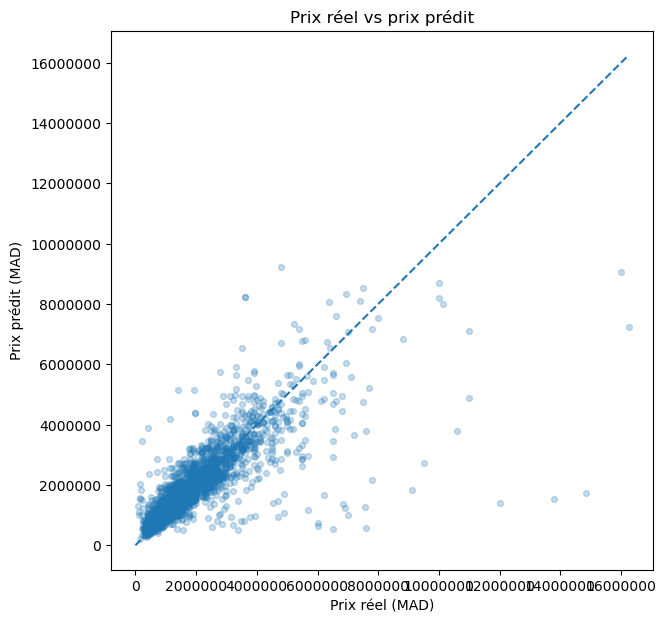

In [111]:
if RUN_FINAL_TEST:
    plt.figure(figsize=(7, 7))
    plt.scatter(
        test_analysis["y_true"],
        test_analysis["y_pred"],
        alpha=0.25,
        s=18
    )

    limit = max(
        test_analysis["y_true"].max(),
        test_analysis["y_pred"].max()
    )

    plt.plot([0, limit], [0, limit], linestyle="--")
    plt.title("Prix réel vs prix prédit")
    plt.xlabel("Prix réel (MAD)")
    plt.ylabel("Prix prédit (MAD)")
    plt.ticklabel_format(style="plain", axis="both")
    plt.show()

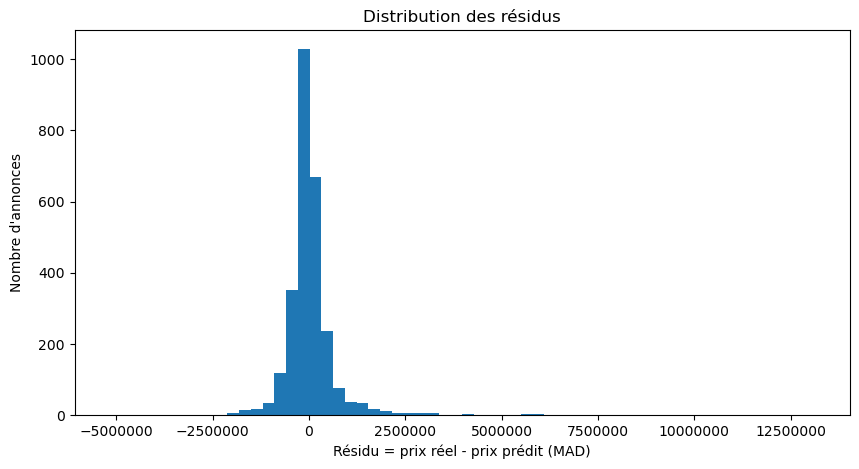

In [ ]:
if RUN_FINAL_TEST:
    plt.figure(figsize=(10, 5))
    plt.hist(test_analysis["residual"], bins=60)
    plt.title("Distribution des résidus")
    plt.xlabel("Résidu = prix réel - prix prédit (MAD)")
    plt.ylabel("Nombre d'annonces")
    plt.ticklabel_format(style="plain", axis="x")
    plt.show()

In [ ]:
if RUN_FINAL_TEST:
    bands = pd.cut(
        test_analysis["y_true"],
        bins=[0, 750_000, 1_500_000, 3_000_000, 5_000_000, np.inf],
        labels=["<750k", "750k-1.5M", "1.5M-3M", "3M-5M", ">5M"]
    )

    error_by_price_band = (
        test_analysis
        .assign(price_band=bands)
        .groupby("price_band", observed=True)
        .agg(
            n=("y_true", "size"),
            MAE=("abs_error", "mean"),
            MedianAE=("abs_error", "median"),
            MdAPE_pct=("pct_error", "median"),
        )
    )

    error_by_price_band
else:
    print("Activer RUN_FINAL_TEST.")

### 6.12 Évaluation par segment

Les métriques sont calculées par ville et par type de bien. Seuls les segments avec au moins 30 observations dans le Test sont interprétés.

In [ ]:
MIN_SEGMENT_TEST = 30

def segment_metrics(data, segment_col, min_n=30):
    rows = []

    for segment, part in data.groupby(segment_col, dropna=False):
        if len(part) < min_n:
            continue

        m = regression_metrics(part["y_true"], part["y_pred"])

        rows.append({
            segment_col: segment,
            "n": len(part),
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "R2": m["R2"],
            "MedianAE": m["MedianAE"],
            "MdAPE_pct": m["MdAPE_pct"],
            "Within_20_pct": m["Within_20_pct"],
        })

    return pd.DataFrame(rows).sort_values("MAE") if rows else pd.DataFrame()


if RUN_FINAL_TEST:
    print("Performance par ville")
    display(
        segment_metrics(
            test_analysis,
            "city",
            MIN_SEGMENT_TEST
        ).round(2)
    )

    print("\nPerformance par type de bien")
    display(
        segment_metrics(
            test_analysis,
            "property_type",
            MIN_SEGMENT_TEST
        ).round(2)
    )
else:
    print("Activer RUN_FINAL_TEST.")

Performance par ville


,city,n,MAE,RMSE,R2,MedianAE,MdAPE_pct,Within_20_pct
5,Meknès,46,122003.17,236983.53,0.63,57608.21,9.16,69.57
10,Témara,37,217466.04,297680.37,0.76,179135.16,16.27,72.97
6,Mohammedia,41,218002.63,284092.43,0.74,167283.06,24.22,46.34
3,Kénitra,45,270823.21,914166.96,-0.04,108422.27,16.38,64.44
2,Fès,71,293997.10,755960.09,0.18,87796.35,14.91,64.79
8,Salé,44,328219.79,650036.84,0.66,152023.37,16.40,61.36
1,Casablanca,1374,370449.86,717318.19,0.72,215612.30,13.12,70.45
9,Tanger,249,424529.50,840148.80,0.61,213574.31,15.04,60.64
4,Marrakech,491,446456.22,871626.37,0.51,253420.18,16.12,57.43
7,Rabat,89,625509.70,913870.92,0.80,430828.50,14.04,68.54



Performance par type de bien


,property_type,n,MAE,RMSE,R2,MedianAE,MdAPE_pct,Within_20_pct
1,studio,40,244677.38,380263.81,0.30,151037.96,13.30,75.00
0,appartement,2380,389674.16,840731.78,0.60,207627.04,14.55,64.50
2,unknown,248,396995.51,773955.98,0.78,199598.26,14.90,67.34


### 6.13 Tests de robustesse

Le meilleur modèle peut ensuite être réentraîné sur :

- toutes les données ;
- sans `uncertain`;
- uniquement les observations `unique`.

Ces tests servent à mesurer la sensibilité du résultat, pas à refaire la sélection du modèle.

In [ ]:
RUN_ROBUSTNESS = True

print("RUN_ROBUSTNESS =", RUN_ROBUSTNESS)

RUN_ROBUSTNESS = True


In [ ]:
def prepare_X_from_frame(frame, feature_set, model_name):
    X = frame[feature_list(feature_set)].copy()

    if model_name == "CatBoost":
        return prepare_for_catboost(
            X,
            cat_columns(feature_set)
        )

    return X


if RUN_FINAL_TEST and RUN_ROBUSTNESS:
    specs = {
        "all_data": (
            np.ones(len(train_df), dtype=bool),
            np.ones(len(test_df), dtype=bool),
        ),
        "without_uncertain": (
            (train_df["outlier_decision"] != "uncertain").values,
            (test_df["outlier_decision"] != "uncertain").values,
        ),
        "unique_only": (
            (train_df["duplicate_status_repaired"] == "unique").values,
            (test_df["duplicate_status_repaired"] == "unique").values,
        ),
    }

    rows = []

    for variant, (tr_mask, te_mask) in specs.items():
        tr_part = train_df.loc[tr_mask].copy()
        te_part = test_df.loc[te_mask].copy()

        key = f"{SELECTED_MODEL}|{SELECTED_FEATURE_SET}|{SELECTED_TARGET_MODE}"

        if RUN_TUNING and key in tuned_estimators:
            est = clone(tuned_estimators[key])
        else:
            est = build_estimator(
                SELECTED_MODEL,
                SELECTED_FEATURE_SET,
                SELECTED_TARGET_MODE
            )

        Xtr = prepare_X_from_frame(
            tr_part,
            SELECTED_FEATURE_SET,
            SELECTED_MODEL
        )
        Xte = prepare_X_from_frame(
            te_part,
            SELECTED_FEATURE_SET,
            SELECTED_MODEL
        )

        est.fit(Xtr, tr_part[TARGET])
        pred = np.maximum(est.predict(Xte), 0)

        m = regression_metrics(te_part[TARGET], pred)

        rows.append({
            "variant": variant,
            "train_rows": len(tr_part),
            "test_rows": len(te_part),
            **m,
        })

    robustness_results = pd.DataFrame(rows)
    display(robustness_results.round(2))
else:
    print("Activer RUN_FINAL_TEST et RUN_ROBUSTNESS.")

,variant,train_rows,test_rows,MAE,RMSE,R2,MedianAE,MdAPE_pct,Within_10_pct,Within_20_pct,Within_30_pct
0,all_data,10158,2708,418333.10,908320.39,0.60,212425.18,15.12,35.49,62.96,78.40
1,without_uncertain,9971,2664,348578.19,644871.16,0.75,199600.17,14.25,37.35,65.13,81.49
2,unique_only,8065,2017,427316.74,903527.08,0.61,219039.41,16.19,32.42,59.79,75.81


### 6.14 Interprétation du modèle final

La Permutation Importance mesure l'impact de chaque variable originale sur la MAE du Test. Elle permet d'interpréter `city`, `surface_m2`, `neighborhood`, etc., même avec le pipeline standard.

In [ ]:
RUN_INTERPRETATION = True
print("RUN_INTERPRETATION =", RUN_INTERPRETATION)

RUN_INTERPRETATION = True


,feature,importance_mean,importance_std
0,surface_m2,464156.757610,9459.460166
5,neighborhood,237670.459869,5788.169344
4,city,69471.975930,2688.213843
3,region,61480.833634,3534.855270
2,bathrooms,23586.879846,3082.035631
1,bedrooms,10676.113697,2483.896608
7,parking,6911.128397,987.857837
8,balcony,5678.049445,802.005125
6,property_type,4537.567907,917.353010
9,sea_view,4043.310066,1033.366180


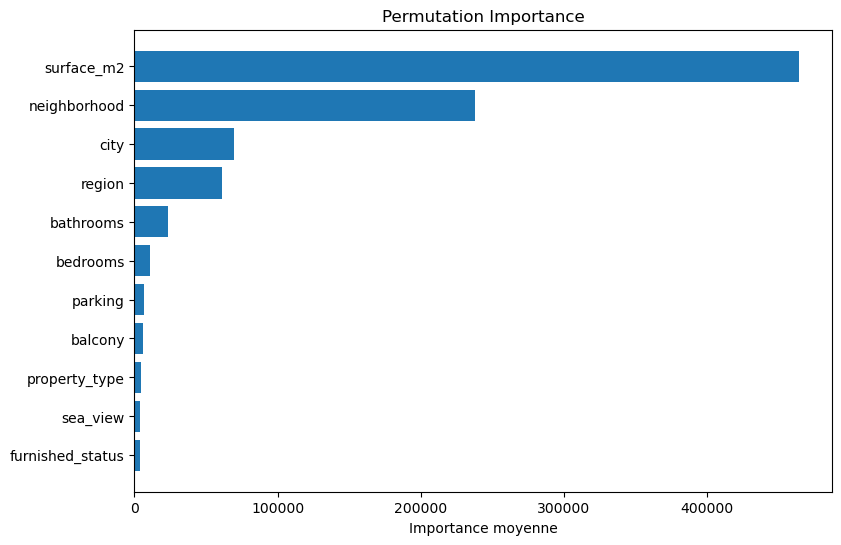

In [ ]:
if RUN_FINAL_TEST and RUN_INTERPRETATION:
    X_test_selected = get_X_test(
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )

    perm = permutation_importance(
        final_estimator,
        X_test_selected,
        y_test_raw,
        scoring="neg_mean_absolute_error",
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    permutation_df = pd.DataFrame({
        "feature": X_test_selected.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(permutation_df)

    top_imp = permutation_df.head(15).sort_values("importance_mean")

    plt.figure(figsize=(9, 6))
    plt.barh(top_imp["feature"], top_imp["importance_mean"])
    plt.title("Permutation Importance")
    plt.xlabel("Importance moyenne")
    plt.show()
else:
    print("Activer RUN_FINAL_TEST et RUN_INTERPRETATION.")

### 6.15 Intervalle d'estimation — prototype Split Conformal

Cette étape optionnelle construit une première fourchette d'incertitude à 90 % autour de l'estimation centrale.

In [ ]:
RUN_CONFORMAL = False
CONFORMAL_ALPHA = 0.10

print("RUN_CONFORMAL =", RUN_CONFORMAL)

RUN_CONFORMAL = False


In [ ]:
if RUN_FINAL_TEST and RUN_CONFORMAL:
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=2026
    )

    proper_idx, calib_idx = next(
        splitter.split(
            train_df,
            groups=train_df["split_group"]
        )
    )

    proper_train = train_df.iloc[proper_idx].copy()
    calibration = train_df.iloc[calib_idx].copy()

    key = f"{SELECTED_MODEL}|{SELECTED_FEATURE_SET}|{SELECTED_TARGET_MODE}"

    if RUN_TUNING and key in tuned_estimators:
        conformal_estimator = clone(tuned_estimators[key])
    else:
        conformal_estimator = build_estimator(
            SELECTED_MODEL,
            SELECTED_FEATURE_SET,
            SELECTED_TARGET_MODE
        )

    X_proper = prepare_X_from_frame(
        proper_train,
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )
    X_calib = prepare_X_from_frame(
        calibration,
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )
    X_test_conf = prepare_X_from_frame(
        test_df,
        SELECTED_FEATURE_SET,
        SELECTED_MODEL
    )

    conformal_estimator.fit(X_proper, proper_train[TARGET])

    calib_pred = np.maximum(
        conformal_estimator.predict(X_calib),
        0
    )

    residuals = np.abs(
        calibration[TARGET].values - calib_pred
    )

    n_cal = len(residuals)
    q_level = min(
        1.0,
        np.ceil((n_cal + 1) * (1 - CONFORMAL_ALPHA)) / n_cal
    )

    q_hat = np.quantile(
        residuals,
        q_level,
        method="higher"
    )

    conf_pred = np.maximum(
        conformal_estimator.predict(X_test_conf),
        0
    )

    lower = np.maximum(conf_pred - q_hat, 0)
    upper = conf_pred + q_hat

    coverage = np.mean(
        (y_test_raw.values >= lower)
        & (y_test_raw.values <= upper)
    )

    print("q_hat (MAD) :", round(q_hat, 0))
    print("Couverture observée :", round(coverage * 100, 2), "%")

    display(
        pd.DataFrame({
            "prix_reel": y_test_raw.values[:10],
            "estimation": conf_pred[:10],
            "borne_basse": lower[:10],
            "borne_haute": upper[:10],
        }).round(0)
    )
else:
    print("Activer RUN_FINAL_TEST et RUN_CONFORMAL.")

Activer RUN_FINAL_TEST et RUN_CONFORMAL.


### 6.16 Sauvegarde du modèle final

Après validation, le modèle et ses métadonnées peuvent être sauvegardés dans le projet. La sauvegarde reste désactivée par défaut.

In [ ]:
RUN_SAVE_MODEL = True
print("RUN_SAVE_MODEL =", RUN_SAVE_MODEL)

RUN_SAVE_MODEL = True


In [ ]:
if RUN_FINAL_TEST and RUN_SAVE_MODEL:
    import joblib

    def find_project_root():
        current = Path.cwd().resolve()

        for candidate in [current] + list(current.parents):
            if (
                (candidate / "data").exists()
                and (candidate / "notebooks").exists()
            ):
                return candidate

        return current

    PROJECT_ROOT = find_project_root()
    MODELS_DIR = PROJECT_ROOT / "models"
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    model_path = MODELS_DIR / "maisondelux_price_model_v1.joblib"
    metadata_path = MODELS_DIR / "maisondelux_price_model_v1_metadata.json"

    joblib.dump(final_estimator, model_path)

    metadata = {
        "model_name": SELECTED_MODEL,
        "feature_set": SELECTED_FEATURE_SET,
        "target_mode": SELECTED_TARGET_MODE,
        "target": TARGET,
        "features": feature_list(SELECTED_FEATURE_SET),
        "rare_thresholds": RARE_THRESHOLDS,
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "split_seed": 18,
        "test_metrics": {
            k: float(v) for k, v in final_metrics.items()
        },
        "notes": (
            "price_mad est un prix d'annonce "
            "et non nécessairement le prix final de transaction."
        ),
    }

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print("Modèle :", model_path)
    print("Métadonnées :", metadata_path)
else:
    print("Activer RUN_FINAL_TEST et RUN_SAVE_MODEL.")

Modèle : C:\Users\Pc\Desktop\MaisonDeLUX\models\maisondelux_price_model_v1.joblib
Métadonnées : C:\Users\Pc\Desktop\MaisonDeLUX\models\maisondelux_price_model_v1_metadata.json


### 6.17 Synthèse finale de la modélisation

La phase de modélisation a permis de comparer plusieurs familles de modèles dans un protocole strict, avec séparation Group-Aware entre Train et Test et sans utilisation de variables provoquant une fuite de la cible.

Après benchmark, validation croisée et optimisation des hyperparamètres, la configuration retenue est :

- **Modèle : XGBoost**
- **Variables : EXTENDED**
- **Cible : LOG (`log1p(price_mad)`)**
- **CV 5-fold MAE : ~429 572 MAD**
- **CV 5-fold R² : ~0,547**

Sur le jeu de test final composé de **2 685 observations**, le modèle obtient :

- **R² : 0,610**
- **MAE : 427 234 MAD**
- **RMSE : 1 024 910 MAD**
- **Median Absolute Error : 201 412 MAD**
- **MdAPE : 14,1 %**
- **37,2 %** des estimations à ±10 %
- **63,2 %** à ±20 %
- **79,1 %** à ±30 %

Ces résultats montrent que le prototype capture une part importante de la structure du marché immobilier observé, malgré la forte hétérogénéité des prix. Le R² ne doit cependant pas être interprété selon un seuil universel : sa valeur dépend fortement de la complexité du problème, de la qualité des données et des variables disponibles.

L'analyse par ville confirme également que la performance varie selon la couverture géographique. Le modèle obtient notamment un R² d'environ **0,69 à Casablanca**, **0,65 à Tanger** et **0,79 à Rabat**, alors que les villes moins représentées restent plus difficiles à modéliser.

Les tests de robustesse montrent que la suppression expérimentale des observations classées `uncertain` fait progresser le R² jusqu'à **0,77**, ce qui confirme que certaines observations atypiques ou insuffisamment documentées affectent fortement l'erreur globale. Ce résultat constitue toutefois une analyse de sensibilité et non une performance directement exploitable en production.

L'interprétation du modèle montre que les variables les plus importantes sont principalement :

1. la **surface** ;
2. le **quartier** ;
3. la **ville** ;
4. la **région** ;
5. le nombre de **salles de bains** et de **chambres**.

La localisation apparaît donc comme un facteur essentiel de l'estimation immobilière, ce qui confirme les observations réalisées lors de l'analyse exploratoire.

### Limites et perspective

MaisonDeLUX V1 doit être considéré comme un **prototype fonctionnel de PFE** permettant de valider la faisabilité de l'approche.

Les performances actuelles restent limitées par plusieurs facteurs : une source principale de données, une représentation géographique déséquilibrée, un nombre important de caractéristiques d'équipements inconnues, une majorité d'appartements dans le dataset et l'utilisation de prix d'annonces plutôt que de prix réels de transaction.

Une version future de MaisonDeLUX pourra améliorer le système en construisant une base de données beaucoup plus large et diversifiée à partir de plusieurs sources, avec une meilleure couverture des villes, quartiers et types de biens.

L'ajout de nouvelles variables telles que les coordonnées géographiques, l'étage, l'âge et l'état du bien, la proximité des services et transports, les caractéristiques du quartier, les données temporelles et certains indicateurs économiques pourra également augmenter le pouvoir explicatif du modèle.

Cette première version ne constitue donc pas une finalité, mais **la première étape d'un système d'estimation immobilière évolutif**, destiné à être progressivement enrichi par davantage de données, de nouvelles sources et le retour des utilisateurs de la plateforme.